# Course: COMP 333 — Project (TEAM D)

### **Team D:**
- Ronnie Chan (27206003)
- Patrice Gallant (40301020)
- Nesrine Larbi (40079009)

<br><br>

### **Project Overview:**
This project consists of two main parts.
- [Section A: Project Phase 1](#Phase-1): Perform data acquisition, EDA and baseline modeling.
- [Section B: Project Phase 2](#Phase-2): Perform feature engineering, implement supervised and unsupervised learning and interpret results.

<br><br>

### **Action Required**:
After completing [Section A: Project Phase 1](#Phase-1), restart the session (`Runtime` > `Restart Session`) to optimize memory and CPU resources before beginning [Section B: Project Phase 2](#Phase-2).

<br><br>

### <a name="division-labor">**Division-of-Labour Statement**</a>

| Student | Phase 1 Tasks (Section A) | Phase 2 Tasks (Section B) |
| :--- | :--- |  :--- |
| **Ronnie Chan** | 1. Data Acquisition (Section 2) <br> 2. Python scripts: **taxi_data.py**, **taxi_utils.py** <br> 3. Data Wrangling/Cleaning (Sections 3.1, 3.3, 3.4, 3.5, 3.6, 3.7) <br> 4. Baseline Model (Section 5) <br> 5. README.md <br><br> | 1. Advanced Supervised Learning (Section 3) <br> 2. Model Comparision and Interpretation (Section 5) <br><br>|
| **Patrice Gallant** | 1. Data Wrangling/Cleaning (Section 3.2) <br> 2. Baseline model (Section 5) <br><br> | 1. Unsupervised Learning (Section 4) <br> 2. Interpretation (Section 5) <br><br>|
| **Nesrine Larbi** | 1. Python script: **taxi_utils.py** <br> 2. Data Wrangling/Cleaning (Sections 3.8, 3.9, 3.10) <br> 3. EDA (Section 4) <br><br> |1. Feature Engineering (Section 2) <br> 2. Interpretation (Section 5) <br><br>|

<br><br>

___
___

# <a name="Phase-1">A.Project Phase 1: Data Acquisition & Baseline</a>

### **Task Description**
Phase 1 of this project involves the following steps:
1. Perform Data Acquisition - The uncompressed size of the acquired dataset must be at least 1 GB.
2. Perform Data Wrangling/Cleaning.
3. Perform Data Exploratory Analysis (EDA).
4. Perform a Baseline model on the dataset.

<br><br>

### **Source of the Datasets**
1. NYC Yellow Taxi Trip Data: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
2. Weather Data (API): https://open-meteo.com/en/docs/historical-weather-api?latitude=40.7143&longitude=-74.006&start_date=2025-06-01&timezone=America%2FNew_York&end_date=2025-07-31&hourly=temperature_2m,precipitation

<br><br>

### **Division-of-Labour Statement (Phase 1)**
See [Divison-of-Labour](#division-labor) in the header.


## 1.Import Libraries

In [ ]:
# For Open-Meteo API
%pip install -q openmeteo-requests requests-cache retry-requests

In [ ]:
# General Libraries
import pandas as pd
import matplotlib.pyplot as plt
import gc
import numpy as np
import math

# Libraries for Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Python script for DDA and EDA (refactored code)
from taxi_utils import TaxiDDA, TaxiEDA

## 2.Data Acquisition
___

- **Objective**: This section covers the retrieval of our dataset from the [NYC Taxi and Limousine Commission (TLC)](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) website and historical New York weather via the [Open-Meteo API](https://open-meteo.com/en/docs/historical-weather-api?latitude=40.7143&longitude=-74.006&start_date=2025-06-01&timezone=America%2FNew_York&end_date=2025-07-31&hourly=temperature_2m,precipitation)


- **Python Script**: `taxi_data.py`

- **Data Selection:**
  1. **NYC Yellow Taxi Trip Recods:** We selected data from **June and July 2025** to represent the Peak Summer Tourism Season 2025. The data is provided in PARQUET format, a columnar storage that allows us to handle millions of raw entries efficiently through compression.
  2. **NYC Weather Data:** We retrieved hourly weather data for **New York** from **June and July 2025** using [Open-Meteo API](https://open-meteo.com/en/docs/historical-weather-api?latitude=40.7143&longitude=-74.006&start_date=2025-06-01&timezone=America%2FNew_York&end_date=2025-07-31&hourly=temperature_2m,precipitation).

<br>

- **Programmatic Retrieval:** The downloading process is implemented in **`taxi_data.py`** using the `curl` command for the trip records and the Python sample code from the Open-Meteo API documentation. The **`taxi_data.py`** script automates the acquisition of these specific months to ensure reproducibility. Given the 12.7 GB RAM constraint of our environment (Google Colab), we built our own dataset with a manageable **raw size of 1.4+ GB on disk**. This ensures us to have enough memory room for subsequent analysis and visualization without crashing our Colab session.

<br>

- **Challenges**: Processing a **1.4+GB dataset** is challenging within a 12.7 GB RAM limit. Since most pandas operations create temporary copies (which double data size), it is crucial to take the following steps to avoid session crashes:
  - **Garbage Collection**: We used `gc.collect()` regurlarly to prevent memory accumulation.
  - **Downcast data types**: We downcasted dtypes of the numerical features (`int32` to `int8` and `float64` to `float32`) to save memory space.
  - **Sampling**: We sampled 10K out of the 7+ millions of rows for visualization during DDA, EDA and training a baseline model. Plotting is immensely memory-intensive. Therefore, sampling prevents memory overflow.



In [ ]:
# Perform Data Retrieval - download our data (see taxi_data.py)
!python taxi_data.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 70.1M  100 70.1M    0     0  82.1M      0 --:--:-- --:--:-- --:--:-- 82.1M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 63.8M  100 63.8M    0     0  90.5M      0 --:--:-- --:--:-- --:--:-- 90.4M

>> All taxi files are saved to local disk.
>> File: 'nyc_weather.csv' is saved to local disk.


### 2.1. NYC Yellow Taxi Trip Records (June and July 2025)

First, we merged the downloaded data for June and July 2025 into one dataset `taxi_df`.

In [ ]:
# Read saved datasets into pandas DataFrame
yellow_taxi_path = lambda m: f"yellow_tripdata_2025-{m}.parquet"
june_df = pd.read_parquet(yellow_taxi_path("06"))
july_df = pd.read_parquet(yellow_taxi_path("07"))

# Merge the 2 datasets into a master dataset
taxi_df = pd.concat([june_df, july_df], ignore_index=True)

# Free up memory
del june_df
del july_df
gc.collect()

# Display the first 10 rows
taxi_df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-06-01 00:02:50,2025-06-01 00:39:51,1.0,10.00,1.0,N,138,50,1,47.8,11.00,0.5,20.15,6.94,1.0,87.39,2.5,1.75,0.75
1,2,2025-06-01 00:11:27,2025-06-01 00:35:35,1.0,3.93,1.0,N,158,237,1,24.7,1.00,0.5,6.09,0.00,1.0,36.54,2.5,0.00,0.75
2,1,2025-06-01 00:43:47,2025-06-01 00:49:16,0.0,0.70,1.0,N,230,163,1,7.2,4.25,0.5,2.59,0.00,1.0,15.54,2.5,0.00,0.75
3,1,2025-06-01 00:01:15,2025-06-01 00:42:16,1.0,17.00,2.0,N,132,232,1,70.0,3.25,0.5,5.00,0.00,1.0,79.75,2.5,0.00,0.75
4,7,2025-06-01 00:16:32,2025-06-01 00:16:32,1.0,2.22,1.0,N,48,234,1,20.5,0.00,0.5,5.25,0.00,1.0,31.50,2.5,0.00,0.75
5,1,2025-06-01 00:05:23,2025-06-01 00:16:57,0.0,0.90,1.0,N,164,90,2,11.4,4.25,0.5,0.00,0.00,1.0,17.15,2.5,0.00,0.75
6,1,2025-06-01 00:23:04,2025-06-01 00:35:25,0.0,1.90,1.0,N,246,113,1,12.8,4.25,0.5,3.70,0.00,1.0,22.25,2.5,0.00,0.75
7,1,2025-06-01 00:37:37,2025-06-01 00:42:28,0.0,0.70,1.0,N,113,113,1,7.2,4.25,0.5,2.55,0.00,1.0,15.50,2.5,0.00,0.75
8,1,2025-06-01 00:44:28,2025-06-01 00:50:01,0.0,0.50,1.0,N,249,249,1,7.2,4.25,0.5,2.55,0.00,1.0,15.50,2.5,0.00,0.75
9,1,2025-06-01 00:52:28,2025-06-01 01:03:29,1.0,2.50,1.0,N,249,142,1,13.5,4.25,0.5,5.75,0.00,1.0,25.00,2.5,0.00,0.75


### 2.2. NYC Hourly Weather Data

By using the sample code from [Open-Meteo API](https://open-meteo.com/en/docs/historical-weather-api?latitude=40.7143&longitude=-74.006&start_date=2025-06-01&timezone=America%2FNew_York&end_date=2025-07-31&hourly=temperature_2m,precipitation), we retrieved hourly weather data for New York city.

Here are the parameters for fetching hourly weather via API.

```python
params = {
  "latitude": 40.7143,            # New York latitude
  "longitude": -74.006,           # New York longitude
  "start_date": "2025-06-01",     # June 2025
  "end_date": "2025-07-31",       # July 2025
  "hourly": ["temperature_2m", "precipitation"],    # temperature (°C), precipitation (mm)
  "timezone": "America/New_York",
}
```

In [ ]:
# Retrieve weather data using Open-Meteo API (see taxi_data.py)
weather_df = pd.read_csv("nyc_weather.csv")
weather_df.head(5)

,Unnamed: 0,date,temperature_2m,precipitation
0,0,2025-06-01 00:00:00+00:00,11.60,0.0
1,1,2025-06-01 01:00:00+00:00,11.05,0.0
2,2,2025-06-01 02:00:00+00:00,10.70,0.0
3,3,2025-06-01 03:00:00+00:00,10.35,0.0
4,4,2025-06-01 04:00:00+00:00,10.05,0.0


In [ ]:
# Correct the datetime (remove 00+00:00)
weather_df['date'] = pd.to_datetime(weather_df['date']).dt.tz_localize(None)
weather_df.drop(columns=['Unnamed: 0'], inplace=True)

### 2.3. Merge Taxi Data with Weather Data

We performed feature engineering on the `taxi_df` to extract specific temporal features (day, hour and day of the week). This process allows us to merge efficiently the `taxi_df` with `weather_df` (hourly weather data).

In [ ]:
# Extract day, hours and day of week from taxi_df
taxi_df['day'] = taxi_df['tpep_pickup_datetime'].dt.day.astype('int8')
taxi_df['pickup_hour'] = taxi_df['tpep_pickup_datetime'].dt.floor('h')
taxi_df['dropoff_hour'] = taxi_df['tpep_dropoff_datetime'].dt.floor('h')
taxi_df['day_of_week'] = taxi_df['tpep_pickup_datetime'].dt.dayofweek.astype('int8')

In [ ]:
# Merge the weather_df with the taxi_df
taxi_df = taxi_df.merge(
    weather_df,
    left_on='pickup_hour',
    right_on='date',
    how='left'
)

# Free up memory - delete temporary variables
taxi_df.drop(columns=['date'], inplace=True)
del yellow_taxi_path
del weather_df
%reset -f out
gc.collect()

Flushing output cache (2 entries)


0

The following shows the summary of `taxi_df`. The `info()` confirms that our merged dataset has the **uncompressed size of 1.4+GB**.

In [ ]:
taxi_df.info(memory_usage=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8221923 entries, 0 to 8221922
Data columns (total 26 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

Equivalently, the formula below shows the (uncompressed) memory usage of our dataset is **1.6 GB**.

In [ ]:
(taxi_df.memory_usage(deep=True).sum() / 1024**3).item()

1.6607033628970385

### 2.4. NYC Yellow Taxi Trips Data Dictionary
The [Yellow Taxi Trips Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf) describes the meaning of each column:

| Feature Types | Features |
| :--- | :--- |
| **Identifier** | `VendorID`|
| **Temporal** |`tpep_pickup_datetime`, `tpep_dropoff_datetime`|
| **Geographical**| `PULocationID`, `DOLocationID`, `trip_distance`|
| **Categorical**| `RatecodeID`, `payment_type`, `passenger_count` |
| **Money-Value** | `fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `total_amount`, `congestion_surcharge`, `airport_fee`, `cbd_congestion_fee` |
|**Others** | `store_and_fwd_flag` |



In [ ]:
# Show the master dataset (raw data)
taxi_df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,day,pickup_hour,dropoff_hour,day_of_week,temperature_2m,precipitation
0,1,2025-06-01 00:02:50,2025-06-01 00:39:51,1.0,10.00,1.0,N,138,50,1,...,87.39,2.5,1.75,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
1,2,2025-06-01 00:11:27,2025-06-01 00:35:35,1.0,3.93,1.0,N,158,237,1,...,36.54,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
2,1,2025-06-01 00:43:47,2025-06-01 00:49:16,0.0,0.70,1.0,N,230,163,1,...,15.54,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
3,1,2025-06-01 00:01:15,2025-06-01 00:42:16,1.0,17.00,2.0,N,132,232,1,...,79.75,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
4,7,2025-06-01 00:16:32,2025-06-01 00:16:32,1.0,2.22,1.0,N,48,234,1,...,31.50,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0


In [ ]:
# Save the raw master dataset
# taxi_df.to_parquet("taxi_raw.parquet", index=False)

## 3.Data Wrangling
___

The first steps of data wrangling involve the following:
1. Remove unrelevant columns, such as `store_and_fwd_flag`, `PULocationID` and `DOLocationID`. These features do not give valuable information.
2. Inspect the statistical summary of the dataset.

In [ ]:
# 1. Drop unrelevant columns
taxi_df = taxi_df.drop(columns=['store_and_fwd_flag', 'PULocationID', 'DOLocationID'])

# 2. Display statistical summary
# Warning: It will take a while to display... Thanks for your patience
dda = TaxiDDA()
dda.quantDDA(taxi_df)

,feature,num_observations,num_entries,num_unique,num_missing,num_outlier,num_extreme,mode,mean,std,min,Q1,median,Q3,max,skew,kurtosis
0,VendorID,8221923,8221923,4,0,1682797,0,2,1.89,0.75,1,2.0,2.0,2.0,7,4.559,30.626
1,tpep_pickup_datetime,8221923,8221923,3665326,0,nan,nan,2025-06-05T18:42:00.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,tpep_dropoff_datetime,8221923,8221923,3664597,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,passenger_count,8221923,5970222,11,2251701,1265142,87009,1.0,1.31,0.75,0.0,1.0,1.0,1.0,9.0,2.839,9.436
4,trip_distance,8221923,8221923,6081,0,933637,81982,0.0,7.3,682.85,0.0,1.07,1.92,3.9,397994.37,227.143,64252.979
5,RatecodeID,8221923,5970222,8,2251701,451800,0,1.0,2.79,12.74,1.0,1.0,1.0,1.0,99.0,7.407,52.963
6,payment_type,8221923,8221923,6,0,260652,2,1,0.91,0.78,0,0.0,1.0,1.0,5,1.501,4.317
7,fare_amount,8221923,8221923,13294,0,734636,163347,-4.75,18.77,115.24,-1591.3,9.3,14.2,23.3,325478.05,2739.617,7737009.833
8,extra,8221923,8221923,91,0,106141,128871,0.0,1.12,1.82,-7.5,0.0,0.0,2.5,42.46,1.691,3.803
9,mta_tax,8221923,8221923,69,0,254469,434,0.5,0.48,1.83,-21.74,0.5,0.5,0.5,5243.38,2841.022,8121278.642


In [ ]:
# Free up memory - delete temporary variables
del dda
%reset -f out
gc.collect()

Flushing output cache (4 entries)


0


The summary shows that the dataset contains incorrect entries, NaN values, outliers, etc.
___
Thus, the data wrangling/cleaning for our analysis consists of the following tasks:
1. Handle duplicates and mirrored data
2. Handle negative fare/fee values
3. Handle 0-distance records
4. Handle 0-passenger records
5. Handle NaN values
6. Map numerical codes to their descriptive labels
7. Downcast data types and free up memory
8. Perform statistic summary and visualization by checking with `quantDDA()` and `vizDDA()`
9. Handle outliers
10. Perform feature selection


### 3.1. Handle Duplicates

The next step is to handle duplicated entries. The dataset has 4 duplicates.

In [ ]:
# Compute the number of duplicates
cols = ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'total_amount']
num_duplicates = taxi_df.duplicated(subset=cols).sum()
int(num_duplicates)

4

Let's inspect the duplicated rows.

In [ ]:
# Retrieve the duplicated entries
duplicates = taxi_df[taxi_df.duplicated(subset=cols, keep=False)]

# Sort by pickup time to inspect the duplicates
duplicates.sort_values(by='tpep_pickup_datetime').head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,day,pickup_hour,dropoff_hour,day_of_week,temperature_2m,precipitation
2296472,1,2025-06-23 07:27:34,2025-06-23 07:27:43,1.0,0.00,1.0,4,3.0,0.00,0.5,...,4.50,0.0,0.00,0.00,23,2025-06-23 07:00:00,2025-06-23 07:00:00,0,27.6,0.0
2297545,1,2025-06-23 07:27:34,2025-06-23 07:27:43,1.0,0.00,1.0,3,3.0,0.00,0.5,...,4.50,0.0,0.00,0.00,23,2025-06-23 07:00:00,2025-06-23 07:00:00,0,27.6,0.0
2399557,1,2025-06-24 08:46:13,2025-06-24 09:00:08,0.0,1.30,1.0,1,13.5,3.25,0.5,...,21.90,2.5,0.00,0.75,24,2025-06-24 08:00:00,2025-06-24 09:00:00,1,31.5,0.0
2402374,1,2025-06-24 08:46:13,2025-06-24 09:00:08,1.0,1.30,1.0,1,13.5,3.25,0.5,...,21.90,2.5,0.00,0.75,24,2025-06-24 08:00:00,2025-06-24 09:00:00,1,31.5,0.0
4681695,2,2025-07-05 17:19:29,2025-07-05 17:19:34,1.0,0.00,1.0,2,3.0,0.00,0.5,...,6.25,0.0,1.75,0.00,5,2025-07-05 17:00:00,2025-07-05 17:00:00,5,31.1,0.0
4681810,2,2025-07-05 17:19:29,2025-07-05 17:19:34,1.0,0.00,1.0,2,3.0,0.00,0.5,...,6.25,0.0,1.75,0.00,5,2025-07-05 17:00:00,2025-07-05 17:00:00,5,31.1,0.0
6284039,2,2025-07-22 19:56:50,2025-07-22 20:06:40,3.0,0.82,1.0,1,10.0,2.50,0.5,...,17.25,2.5,0.00,0.75,22,2025-07-22 19:00:00,2025-07-22 20:00:00,1,25.1,0.0
6287100,2,2025-07-22 19:56:50,2025-07-22 20:06:40,1.0,0.82,1.0,4,10.0,2.50,0.5,...,17.25,2.5,0.00,0.75,22,2025-07-22 19:00:00,2025-07-22 20:00:00,1,25.1,0.0


The duplicated rows are almost identical with the same `VendorID`, pick up times and drop off times despite of the few disparencies in few columns. These represent system duplicates with wrong data entries because a same customer cannot take 2 different rides at the same time. Thus, we removed the 4 duplicates.

In [ ]:
# Drop the duplicated row
taxi_df = taxi_df.drop_duplicates(subset=cols, keep='first')

# Free up memory
del num_duplicates
del duplicates
%reset -f out
gc.collect()

Flushing output cache (3 entries)


0

**Mirrored Entries**

We also found 150,444 mirrorred rows in the dataset.

In [ ]:
# Compute the number of mirrored rows
cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance']
nb_mirrored = taxi_df.duplicated(subset=cols).sum()
int(nb_mirrored)

150444

In [ ]:
# Retrieve the duplicated/mirrored entries
duplicates = taxi_df[taxi_df.duplicated(subset=cols, keep=False)]

# Sort by pickup time to inspect the duplicates/mirrored
duplicates.sort_values(by='tpep_pickup_datetime').head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,day,pickup_hour,dropoff_hour,day_of_week,temperature_2m,precipitation
3339,2,2025-06-01 00:00:30,2025-06-01 00:20:55,1.0,3.63,1.0,4,21.9,1.0,0.5,...,27.65,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
3338,2,2025-06-01 00:00:30,2025-06-01 00:20:55,1.0,3.63,1.0,4,-21.9,-1.0,-0.5,...,-27.65,-2.5,0.00,-0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
4562,2,2025-06-01 00:00:38,2025-06-01 00:08:35,2.0,1.51,1.0,2,9.3,1.0,0.5,...,15.05,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
4561,2,2025-06-01 00:00:38,2025-06-01 00:08:35,2.0,1.51,1.0,2,-9.3,-1.0,-0.5,...,-15.05,-2.5,0.00,-0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
4476,2,2025-06-01 00:00:42,2025-06-01 00:16:44,1.0,11.23,1.0,3,42.2,1.0,0.5,...,46.45,0.0,1.75,0.00,1,2025-06-01,2025-06-01,6,11.6,0.0
4475,2,2025-06-01 00:00:42,2025-06-01 00:16:44,1.0,11.23,1.0,3,-42.2,-1.0,-0.5,...,-46.45,0.0,-1.75,0.00,1,2025-06-01,2025-06-01,6,11.6,0.0
2078,2,2025-06-01 00:00:52,2025-06-01 00:01:42,1.0,0.10,1.0,4,-3.0,-1.0,-0.5,...,-8.75,-2.5,0.00,-0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
2079,2,2025-06-01 00:00:52,2025-06-01 00:01:42,1.0,0.10,1.0,4,3.0,1.0,0.5,...,8.75,2.5,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0
4811,2,2025-06-01 00:00:54,2025-06-01 00:00:59,1.0,0.00,1.0,3,-3.0,-1.0,-0.5,...,-5.50,0.0,0.00,0.00,1,2025-06-01,2025-06-01,6,11.6,0.0
4812,2,2025-06-01 00:00:54,2025-06-01 00:00:59,1.0,0.00,1.0,3,3.0,1.0,0.5,...,5.50,0.0,0.00,0.00,1,2025-06-01,2025-06-01,6,11.6,0.0


The **mirrored records** are twins to each other.
- One contains a **positive** `total_amount`.
- The other contains an **identical negative value**.

These represent transactions that were accidentally registered and then cancelled by the drivers. We removed these 150,444 mirrored records to prevent statistical inflation caused by the negative financial values (such as total amount, fees, fares, tips, etc) and to ensure a more meaningful analysis of customer behavior.

In [ ]:
# Apply absolute value on the total amount
taxi_df['abs_amount'] = taxi_df['total_amount'].abs()
cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'abs_amount']

# Find the mirrored rows (Positive/Negative pairs)
is_mirror = taxi_df.duplicated(subset=cols, keep=False)
taxi_df[is_mirror][['VendorID', 'trip_distance','total_amount','abs_amount']].head(10)

,VendorID,trip_distance,total_amount,abs_amount
80,2,0.14,-9.45,9.45
81,2,0.14,9.45,9.45
224,2,0.83,-12.95,12.95
225,2,0.83,12.95,12.95
264,2,0.00,-74.00,74.00
265,2,0.00,74.00,74.00
331,2,0.02,-8.75,8.75
332,2,0.02,8.75,8.75
458,2,3.17,-22.70,22.70
459,2,3.17,22.70,22.70


In [ ]:
# Drop mirrored rows
taxi_df = taxi_df[~is_mirror]

### 3.2. Handle remaning negative fare values

When handling the duplicates and mirrored rows in step 3.1, we observed that there is still a signifcant number of negative values for financial features, such as `fare amount`.

In [ ]:
# Check the count of negative values
taxi_df[taxi_df['fare_amount'] < 0].shape[0]

373516

The dataset contains a significant number of negative values. We chose to retain these records rather than dropping them, as other features within the same entries may contain valuable information. To handle this, we added an `is_negative` column to flag these rows, allowing us to isolate anomalies without losing data integrity.

In [ ]:
taxi_df['is_negative'] = ((taxi_df['fare_amount'] < 0) | (taxi_df['Airport_fee'] < 0) | (taxi_df['cbd_congestion_fee'] < 0)
                          | (taxi_df['tip_amount'] < 0) | (taxi_df['total_amount'] < 0) | (taxi_df['congestion_surcharge'] < 0)
                          | (taxi_df['improvement_surcharge'] < 0) | (taxi_df['extra'] < 0) | (taxi_df['mta_tax'] < 0))
taxi_df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,...,Airport_fee,cbd_congestion_fee,day,pickup_hour,dropoff_hour,day_of_week,temperature_2m,precipitation,abs_amount,is_negative
0,1,2025-06-01 00:02:50,2025-06-01 00:39:51,1.0,10.00,1.0,1,47.8,11.00,0.5,...,1.75,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0,87.39,False
1,2,2025-06-01 00:11:27,2025-06-01 00:35:35,1.0,3.93,1.0,1,24.7,1.00,0.5,...,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0,36.54,False
2,1,2025-06-01 00:43:47,2025-06-01 00:49:16,0.0,0.70,1.0,1,7.2,4.25,0.5,...,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0,15.54,False
3,1,2025-06-01 00:01:15,2025-06-01 00:42:16,1.0,17.00,2.0,1,70.0,3.25,0.5,...,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0,79.75,False
4,7,2025-06-01 00:16:32,2025-06-01 00:16:32,1.0,2.22,1.0,1,20.5,0.00,0.5,...,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0,31.50,False


###3.3. Handle 0-distance rows

The `taxi_df` contains 0-distance rows, indicating the taximeter did not record the trip distance in miles. We decided to drop these 238,440 0-distance rows to ensure a meaningful predicitons for the Machine Learning models.

In [ ]:
# Inspect the number of 0-distance rows
print("Number of 0-distance rows:", len(taxi_df.loc[taxi_df["trip_distance"]==0]))

# Drop the 0-distance rows
taxi_df = taxi_df[taxi_df['trip_distance'] > 0]
print("Successfully dropped")

Number of 0-distance rows: 238440
Successfully dropped


**Check**: There is no 0-distance rows.

In [ ]:
0 in taxi_df['trip_distance'].unique()

False

### 3.4. Handle 0-passenger rows

Similarly, The `taxi_df` contains 0-passenger rows. We decided to replace these 0-passenger rows (0.54% of the dataset) with the mode to ensure a meaningful predicitons for the Machine Learning models. A trip should have at least 1 passenger.

In [ ]:
zero_passenger_df = taxi_df.loc[taxi_df['passenger_count']==0]
print(f"Number of 0-passenger rows: {len(zero_passenger_df)}")
print(f"Ratio of 0-passenger rows: {len(zero_passenger_df)/len(taxi_df)*100: .2f} %")

Number of 0-passenger rows: 41675
Ratio of 0-passenger rows:  0.54 %


The following indicates that the 0-passenger rows do not have `RatecodeID` 6 (Group ride). Thus, we can safely replace 0 with the mode (which is 1 passenger).

In [ ]:
# Inspect the unique values and mode
print("Unique values:", zero_passenger_df['RatecodeID'].unique())
print("Mode:", zero_passenger_df['RatecodeID'].mode().item())

# Replace 0 passenger with mode 1
taxi_df.loc[taxi_df['passenger_count'] == 0, 'passenger_count'] = 1
print("Successfully replace 0 passenger")

Unique values: [ 1.  2.  3.  5. 99.  4.]
Mode: 1.0
Successfully replace 0 passenger


**Check:** There is no 0-passenger rows.

In [ ]:
0 in taxi_df['passenger_count'].unique()

False

### 3.5. Handle NaN values

In [ ]:
# Check the number of NaN values in each column
taxi_df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,2074024
trip_distance,0
RatecodeID,2074024
payment_type,0
fare_amount,0
extra,0
mta_tax,0


**PART 1**

The ratio of NaN values counts for 27%, and the number of NaN is consistent accross these 4 features:
- `passenger_count`
- `RatecodeID`
- `congestion_surcharge`
- `Airport_fee`

In [ ]:
# Compute ratio of NaN values
nan_count = taxi_df['congestion_surcharge'].isnull().sum()
nan_ratio = round(nan_count/len(taxi_df) * 100)
print(f"Ratio of NaN values: {nan_ratio} %")

Ratio of NaN values: 27 %


For our analysis, we decided to **impute the missing values** in `congestion_surcharge` and `Airport_fee` with 0. These fees are redundant as they are already captured by the `RatecodeID` feature:

- `RatecodeID` 2 (JFK) or 3 (Newark) indicates an airport trip with an additional fee between `1.75$` or `6.75$`.
- `RatecodeID` 1 (Standard rate) is used for trips within the Manhattan congestion zone (with a surcharge) and other boroughs (without a surcharge).

Replacing NaNs by 0 allows us to represent that a passenger did not travel to the airport or enter the Manhanttan congestion zone.


In [ ]:
print('Airport_fee')
print('---------------------')
print('Unique values:', taxi_df['Airport_fee'].unique())
print('Average', taxi_df.loc[taxi_df['Airport_fee'] > 0, 'Airport_fee'].mean().round(2))

print('\n\nCongestion Surcharge')
print('---------------------')
print('Unique values:', taxi_df['congestion_surcharge'].unique())
print('Average', taxi_df.loc[taxi_df['congestion_surcharge'] > 0, 'congestion_surcharge'].mean().round(2))

Airport_fee
---------------------
Unique values: [ 1.75  0.    6.75  5.   -1.75   nan]
Average 1.79


Congestion Surcharge
---------------------
Unique values: [ 2.5   0.   -2.5    nan  0.75  1.  ]
Average 2.5


In [ ]:
# Replace NaNs with 0
taxi_df.loc[:, ['congestion_surcharge', 'Airport_fee']] = taxi_df[['congestion_surcharge', 'Airport_fee']].fillna(0)

Using a similar logic, we imputed `passenger_count` with its mode, which is 1. This allows us to represent a single-passenger trip, which is the most frequence occurence in our dataset. For `RatecodeID`, we use the code 99 to fill the missing values, as that code represents an `Unknown` rate.

In [ ]:
# Show the modes
print('Mode for passenger_count:', taxi_df['passenger_count'].mode().item())

Mode for passenger_count: 1.0


In [ ]:
# Replace NaNs with mode 1
taxi_df.loc[:, ['passenger_count']] = taxi_df[['passenger_count']].fillna(1)

# Replace NaNs with code 99
taxi_df.loc[:, ['RatecodeID']] = taxi_df[['RatecodeID']].fillna(99)

**PART 2 - WEAHTER**

When inspecting the rows with NaN values for hourly weather, we discovered that these records fell outside our specified analysis period **(2025-06-01 and 2025-07-31)**.

The dataset contains:
- 1 record dated from 2009
- 20 records from 2025-05-31.

Thus, we are required to drop these 21 records from our dataset for data integrity.

In [ ]:
# Inspect records with NaN values for hourly weather
nan_weather_df = taxi_df.loc[taxi_df['temperature_2m'].isnull()]
nan_weather_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,...,Airport_fee,cbd_congestion_fee,day,pickup_hour,dropoff_hour,day_of_week,temperature_2m,precipitation,abs_amount,is_negative
190,2,2025-05-31 23:54:40,2025-05-31 23:57:58,1.0,0.46,1.0,1,5.1,1.0,0.5,...,0.00,0.75,31,2025-05-31 23:00:00,2025-05-31 23:00:00,5,NaN,NaN,12.00,False
372,2,2025-05-31 23:53:28,2025-06-01 00:06:34,1.0,2.15,1.0,1,14.2,1.0,0.5,...,0.00,0.00,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN,23.04,False
393,2,2025-05-31 23:57:27,2025-06-01 00:08:30,3.0,1.55,1.0,1,12.1,1.0,0.5,...,0.00,0.75,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN,19.85,False
474,2,2025-05-31 23:54:45,2025-06-01 00:03:28,1.0,0.92,1.0,1,9.3,1.0,0.5,...,0.00,0.75,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN,18.06,False
481,2,2025-05-31 23:49:16,2025-06-01 00:08:01,1.0,2.70,1.0,1,18.4,1.0,0.5,...,0.00,0.75,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN,24.15,False
752,2,2025-05-31 23:49:15,2025-05-31 23:59:08,1.0,1.20,1.0,2,10.7,1.0,0.5,...,0.00,0.75,31,2025-05-31 23:00:00,2025-05-31 23:00:00,5,NaN,NaN,16.45,False
833,2,2025-05-31 23:57:16,2025-06-01 00:05:13,3.0,3.39,1.0,1,14.2,1.0,0.5,...,0.00,0.75,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN,20.17,False
993,2,2025-05-31 23:58:17,2025-06-01 00:10:55,1.0,1.23,1.0,1,12.1,1.0,0.5,...,0.00,0.75,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN,17.85,False
1369,2,2025-05-31 23:59:57,2025-06-01 00:30:01,1.0,4.31,1.0,4,-28.9,-1.0,-0.5,...,0.00,-0.75,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN,34.65,True
1797,2,2025-05-31 23:59:25,2025-06-01 00:15:11,1.0,10.70,4.0,1,58.3,1.0,0.5,...,1.75,0.00,31,2025-05-31 23:00:00,2025-06-01 00:00:00,5,NaN,NaN,62.55,False


The following code shows that the `nan_weahter_df` corresponds to the rows with incorrect date entries.

In [ ]:
# This shows they have the same indexes
taxi_df.loc[taxi_df['pickup_hour'] < '2025-06-01 00:00:00'].index.equals(nan_weather_df.index)

True

In [ ]:
# Free up memory - delete temporary variables and dataframes
taxi_df = taxi_df.drop(nan_weather_df.index)
del cols, duplicates, nb_mirrored, is_mirror
del zero_passenger_df
del nan_weather_df
del nan_count, nan_ratio
%reset -f out
gc.collect()

Flushing output cache (11 entries)


0

The following cell shows that the dataset does not contain entries falling outside of July 2025.

In [ ]:
# Check invalid entries falling outside the upper bound of our study period
taxi_df.loc[taxi_df['pickup_hour'] > '2025-07-31 23:59:59']

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,...,Airport_fee,cbd_congestion_fee,day,pickup_hour,dropoff_hour,day_of_week,temperature_2m,precipitation,abs_amount,is_negative


**Final Check:** The dataset has correct entries for our specific study period and has no more missing values.

In [ ]:
taxi_df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
payment_type,0
fare_amount,0
extra,0
mta_tax,0


### 3.6. Map Labels

This section consists of converting numerical codes (1,2,3, etc) to their corresponding descriptive labels. We perform label mapping in the following features by using the [NYC Yellow Taxi Trips Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf).


- `RatecodeID`
- `payment_type`

#### 3.6.1 Feature: `RatecodeID`

In [ ]:
# Show the unique numerical codes
taxi_df['RatecodeID'].unique()

array([ 1.,  2.,  5., 99.,  4.,  3.,  6.])

In [ ]:
# Define the rate code dictionary
rate_code_map = {
    1: "Standard rate",
    2: "JFK",
    3: "Newark",
    4: "Nassau or Westchester",
    5: "Negotiated fare",
    6: "Group ride",
    99: "Unknown"
}

# Map the rate code ID with the appropriate category
taxi_df.loc[:,'rate_code'] = taxi_df['RatecodeID'].map(rate_code_map).astype('category')

# Free up memory
taxi_df = taxi_df.drop(columns=['RatecodeID'])
%reset -f out
gc.collect()

Flushing output cache (4 entries)


0

**Check:** The rate codes are correctly mapped.

In [ ]:
taxi_df['rate_code'].unique()

['Standard rate', 'JFK', 'Negotiated fare', 'Unknown', 'Nassau or Westchester', 'Newark', 'Group ride']
Categories (7, object): ['Group ride', 'JFK', 'Nassau or Westchester', 'Negotiated fare', 'Newark',
                         'Standard rate', 'Unknown']

#### 3.6.2 Feature: `payment_type`

In [ ]:
# Show the unique numerical codes
taxi_df['payment_type'].unique()

array([1, 2, 3, 4, 5, 0])

In [ ]:
# Define the payment dictionary
payment_map = {
    0: "Flex fare",
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided trip"
}

# Apply mapping and categorize
taxi_df.loc[:,'payment_type']= taxi_df['payment_type'].map(payment_map).astype('category')

/tmp/ipykernel_94459/2726749571.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Credit card', 'Credit card', 'Credit card', 'Credit card', 'Credit card', ..., 'Flex fare', 'Flex fare', 'Flex fare', 'Flex fare', 'Flex fare']
Length: 7683628
Categories (6, object): ['Cash', 'Credit card', 'Dispute', 'Flex fare', 'No charge', 'Unknown']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  taxi_df.loc[:,'payment_type']= taxi_df['payment_type'].map(payment_map).astype('category')


**Check:** The payment types are correctly mapped.

In [ ]:
taxi_df['payment_type'].unique()

['Credit card', 'Cash', 'No charge', 'Dispute', 'Unknown', 'Flex fare']
Categories (6, object): ['Cash', 'Credit card', 'Dispute', 'Flex fare', 'No charge', 'Unknown']

### 3.7. Downcast dtypes

In [ ]:
# Drop unrelevant columns
taxi_df = taxi_df.drop(columns=['VendorID','abs_amount'])

Let's reduce the numerical dtype to a smaller dtype to efficently manage memory usage.

In [ ]:
# Define the numerical columns to convert
float64_cols = [
    'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
    'tolls_amount', 'improvement_surcharge', 'total_amount',
    'congestion_surcharge','Airport_fee', 'cbd_congestion_fee',
    'temperature_2m', 'precipitation'
]

# Convert to a smaller dtype (downcast the dtypes)
taxi_df['passenger_count'] = taxi_df['passenger_count'].astype('int8')
taxi_df[float64_cols] = taxi_df[float64_cols].astype('float32')

In [ ]:
# Delete all temporary variable and Free up memory
del rate_code_map
del payment_map
del float64_cols
%reset -f out
gc.collect()

Flushing output cache (4 entries)


0

Here is the updated `taxi_df`.

In [ ]:
taxi_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7683628 entries, 0 to 8221922
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        int8          
 3   trip_distance          float32       
 4   payment_type           category      
 5   fare_amount            float32       
 6   extra                  float32       
 7   mta_tax                float32       
 8   tip_amount             float32       
 9   tolls_amount           float32       
 10  improvement_surcharge  float32       
 11  total_amount           float32       
 12  congestion_surcharge   float32       
 13  Airport_fee            float32       
 14  cbd_congestion_fee     float32       
 15  day                    int8          
 16  pickup_hour            datetime64[us]
 17  dropoff_hour           datetime64[us]
 18  day_of_week            int8

In [ ]:
taxi_df.head(5)

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,...,Airport_fee,cbd_congestion_fee,day,pickup_hour,dropoff_hour,day_of_week,temperature_2m,precipitation,is_negative,rate_code
0,2025-06-01 00:02:50,2025-06-01 00:39:51,1,10.00,Credit card,47.799999,11.00,0.5,20.15,6.94,...,1.75,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0,False,Standard rate
1,2025-06-01 00:11:27,2025-06-01 00:35:35,1,3.93,Credit card,24.700001,1.00,0.5,6.09,0.00,...,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0,False,Standard rate
2,2025-06-01 00:43:47,2025-06-01 00:49:16,1,0.70,Credit card,7.200000,4.25,0.5,2.59,0.00,...,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0,False,Standard rate
3,2025-06-01 00:01:15,2025-06-01 00:42:16,1,17.00,Credit card,70.000000,3.25,0.5,5.00,0.00,...,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0,False,JFK
4,2025-06-01 00:16:32,2025-06-01 00:16:32,1,2.22,Credit card,20.500000,0.00,0.5,5.25,0.00,...,0.00,0.75,1,2025-06-01,2025-06-01,6,11.6,0.0,False,Standard rate


### 3.8. Initial DDA: `quantDDA()` and `vizDDA()`

Let's us the methods `quantDDA()` and `vizDDA()` to generate the statistic summary to inspect outliers and verify our data cleaning process, and visualization on `taxi_df`. The functions are implemented in the script `taxi_utils.py` under the class `TaxiDDA()`.

#### 3.8.1. Part 1: `quantDDA()`

In [ ]:
dda = TaxiDDA()
dda.quantDDA(taxi_df)

,feature,num_observations,num_entries,num_unique,num_missing,num_outlier,num_extreme,mode,mean,std,min,Q1,median,Q3,max,skew,kurtosis
0,tpep_pickup_datetime,7683628,7683628,3605193,0,nan,nan,2025-06-05T19:27:00.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,tpep_dropoff_datetime,7683628,7683628,3605567,0,nan,nan,2025-06-05T20:02:00.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,passenger_count,7683628,7683628,9,0,1128420,43104,1,1.22,0.64,1,1.0,1.0,1.0,9,3.648,15.498
3,trip_distance,7683628,7683628,5978,0,863850,149220,0.9,7.66,706.34,0.009999999776482582,1.15,2.0,4.0,397994.375,219.599,60052.727
4,payment_type,7683628,7683628,6,0,nan,nan,Credit card,nan,nan,nan,nan,nan,nan,nan,nan,nan
5,fare_amount,7683628,7683628,11810,0,594486,90492,8.6,19.41,117.97,-483.20001220703125,9.3,14.2,23.45,325478.0625,2677.604,7336950.0
6,extra,7683628,7683628,78,0,92930,49983,0.0,1.19,1.82,-7.5,0.0,0.0,2.5,42.459999084472656,1.795,3.611
7,mta_tax,7683628,7683628,64,0,70900,70900,0.5,0.5,1.89,-21.739999771118164,0.5,0.5,0.5,5243.3798828125,2768.556,7671139.0
8,tip_amount,7683628,7683628,5284,0,413814,73427,0.0,2.87,3.94,-8.59000015258789,0.0,2.0,4.0,960.9400024414062,5.96,546.243
9,tolls_amount,7683628,7683628,1418,0,541847,35619,0.0,0.53,2.07,-70.0,0.0,0.0,0.0,716.0499877929688,10.415,1782.039


**Intepretation of Statistical Summary:**
- The dataset still contains negative values for money-value features (see `min`), which is correct and intented. We may need those for future analysis.
- The dataset contains outliers, which will be handled in **Section 3.9 Hanlde Outliers**.
- The dataset contains redundant columns, which will be handled in **Section 3.10 Feature Selection**.

<br>

#### 3.8.2. Part 2: `vizDDA()`
- The full dataset contains **7+ millions of rows** and **22 columns**. While we ran the `quantDDA()` on the entire dataset for statistical accuracy, a full `vizDDA()` would generate a 22x22 grid, making the **visualization overcrowded** and **difficult to interpret**.


- We executed `vizDDA()` on a **smaller sample of 10K entries** using 8 selected columns.

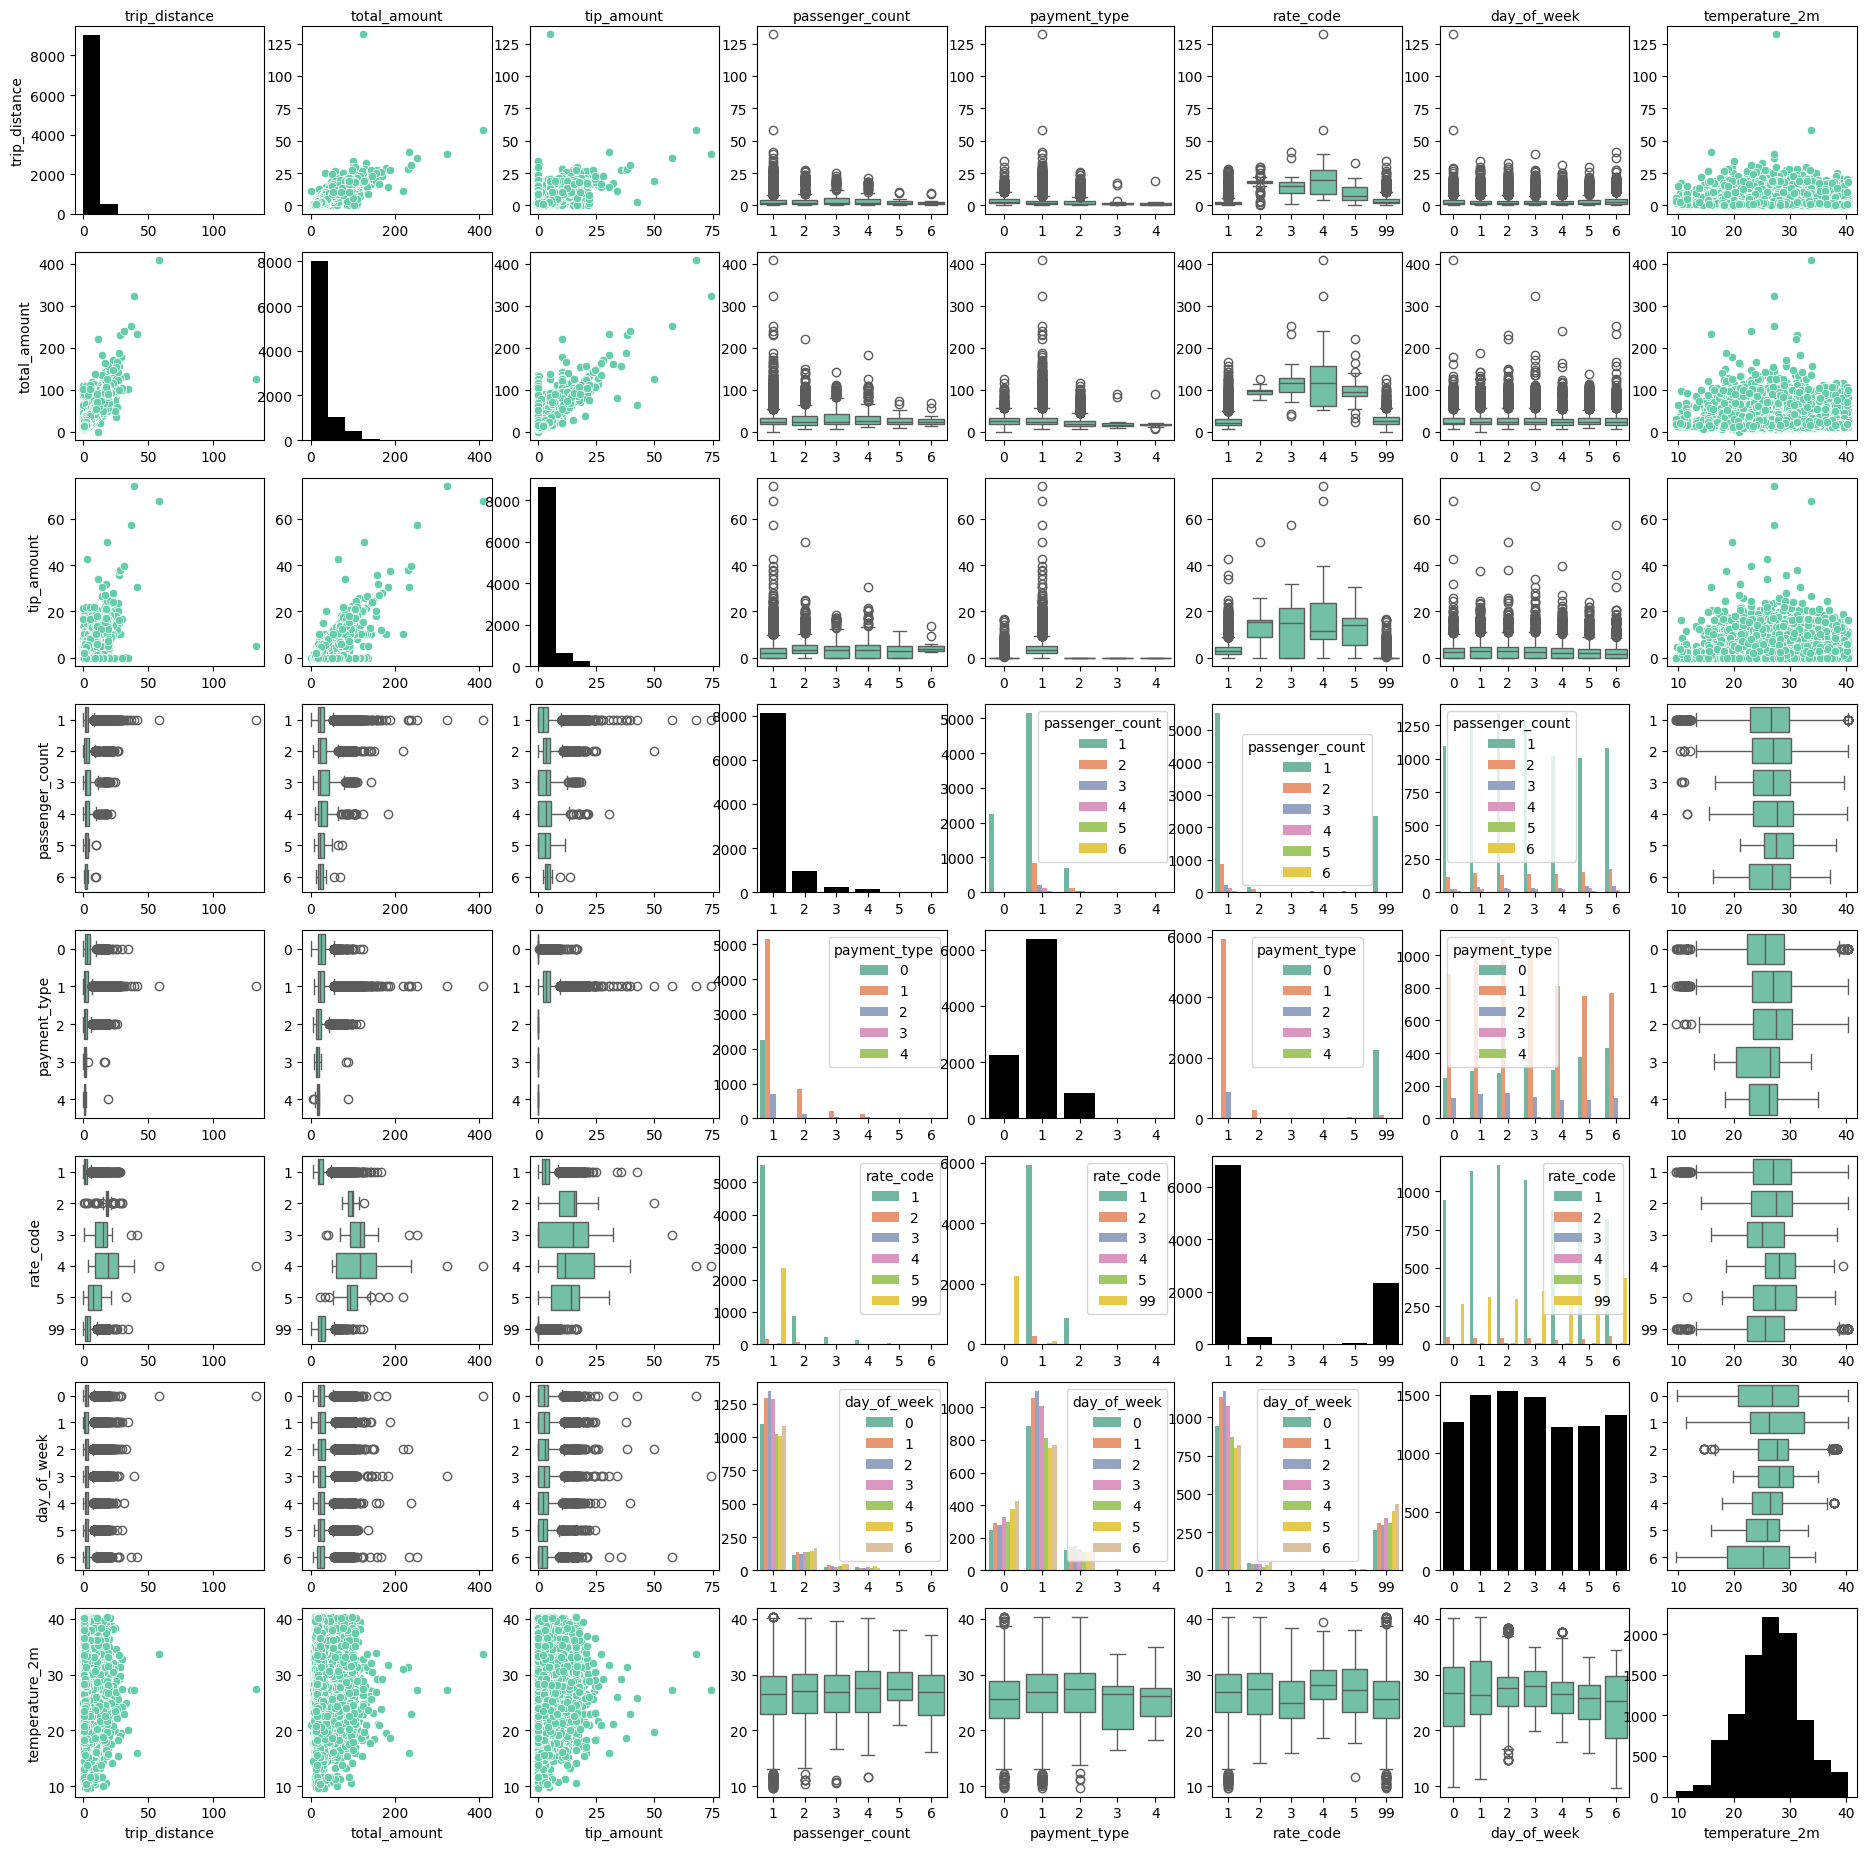

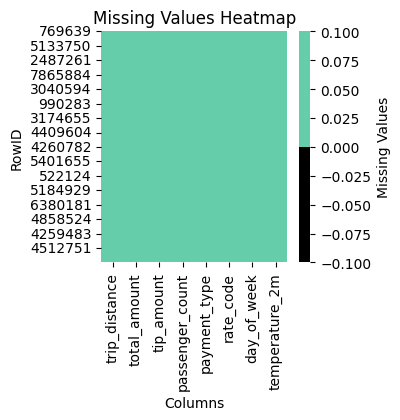

In [ ]:
# Randomly sample a batch of 10K entries
sample_df = taxi_df.sample(n=10000, random_state=42)
sample_df = sample_df.loc[~sample_df["is_negative"]]
cols = ["trip_distance", "total_amount", "tip_amount", "passenger_count", "payment_type", "rate_code", "day_of_week", "temperature_2m"]
dda.vizDDA(sample_df[cols])

**Interpretation:**
- The heatmap confirms that the dataset has no more NaN values.
- The `tip_amount` is more likely higher when passenger travels alone, pays by credit card and is going to the airport.
- A greater `trip_distance` is positively correlated with a larger `tip_amount`.
- To prevent clustered visualization, the categorical labels are mapped back to their corresponding numerical codes for `rate_code` and `payment_type`.
- For a detailed visualization analysis, please refer to **Section 4.1 Univariate Visualization** and **Section 4.2 Bivariate Visualization**.

In [ ]:
# Free up memory
del sample_df, cols, dda
gc.collect()

6924

### 3.9. Handle Outliers

The `quantDDA()` summary (Section 3.7) reports IQR-based outliers and extreme values (top/bottom 1%) for each numerical feature. The right-skewed distributions observed in EDA  confirm that `trip_distance`, `fare_amount`, `total_amount`, `tip_amount`, and `tolls_amount` contain extreme high-end values (e.g., trips of 300+ miles or fares of \$1,000+) that are likely data errors or anomalous events.

**Strategy: cap at the 99th percentile (Winsorization)**

We chose *capping* over *dropping* to:
- Preserve the maximum number of rows for model training
- Avoid removing legitimate edge cases (e.g., long airport trips)
- Reduce the statistical influence of erroneous extremes

The **lower bound** is kept at 0 for financial columns (negative values were already addressed by the mirrored-entry removal in Section 3.1).

| Feature | Cap applied |
|---|---|
| `trip_distance` | 99th percentile |
| `fare_amount` | 99th percentile |
| `total_amount` | 99th percentile |
| `tip_amount` | 99th percentile |
| `tolls_amount` | 99th percentile |


In [ ]:
outlier_cols = ['trip_distance', 'fare_amount', 'total_amount', 'tip_amount', 'tolls_amount']

# Compute 99th percentile caps
caps = taxi_df[outlier_cols].quantile(0.99)
print("99th percentile caps:\n", caps.round(2), "\n")

# Count outliers above cap before capping
before = (taxi_df[outlier_cols] > caps).sum()
print("Rows above cap (before):\n", before, "\n")

# Cap at 99th percentile (lower bound stays at 0 for financial columns)
for col in outlier_cols:
    taxi_df[col] = taxi_df[col].clip(upper=caps[col])

# Verify — no values above cap remain
after = (taxi_df[outlier_cols] > caps).sum()
print("Rows above cap (after):\n", after)
print(f"\nDataset shape after capping: {taxi_df.shape[0]:,} rows × {taxi_df.shape[1]} columns")

# Free up memory
del caps, before, after
gc.collect()


99th percentile caps:
 trip_distance     19.60
fare_amount       75.10
total_amount     104.03
tip_amount        17.34
tolls_amount       6.94
Name: 0.99, dtype: float64 

Rows above cap (before):
 trip_distance    76448
fare_amount      76455
total_amount     75569
tip_amount       73423
tolls_amount     35540
dtype: int64 

Rows above cap (after):
 trip_distance    0
fare_amount      0
total_amount     0
tip_amount       0
tolls_amount     0
dtype: int64

Dataset shape after capping: 7,683,628 rows × 23 columns


280122

### 3.10. Feature Selection

We select the features that will be used for the Machine Learning models (RQ1 and RQ2). The raw datetime columns (`tpep_pickup_datetime`, `tpep_dropoff_datetime`, `pickup_hour`, `dropoff_hour`) are dropped since the relevant temporal information has already been extracted into `day`, `day_of_week`, and `hour_of_day`.

**Features kept (14 columns):**

| Feature | Type | Role |
|---|---|---|
| `trip_distance` | float32 | Core trip metric |
| `total_amount` | float32 | Target (RQ1) / cluster feature (RQ2) |
| `tip_amount` | float32 | Behavioral feature |
| `fare_amount` | float32 | Base fare |
| `congestion_surcharge` | float32 | Fee feature |
| `Airport_fee` | float32 | Fee feature |
| `passenger_count` | int8 | Trip attribute |
| `rate_code` | category | Trip category |
| `payment_type` | category | Trip category |
| `day_of_week` | int8 | Temporal feature |
| `day` | int8 | Temporal feature |
| `hour_of_day` | int8 | Temporal feature |
| `temperature_2m` | float32 | Weather feature |
| `precipitation` | float32 | Weather feature |

**Dropped (4 datetime columns):** `tpep_pickup_datetime`, `tpep_dropoff_datetime`, `pickup_hour`, `dropoff_hour`

> **Note for RQ1:** fee subcomponents (`extra`, `mta_tax`, `improvement_surcharge`, `cbd_congestion_fee`, `tolls_amount`, `fare_amount`, `tip_amount`) are components of `total_amount` and will be excluded at model training time to avoid data leakage.


In [ ]:
# Extract hour of day as integer before dropping pickup_hour
taxi_df['hour_of_day'] = taxi_df['pickup_hour'].dt.hour.astype('int8')

# Drop raw datetime columns — temporal info already captured in day, day_of_week, hour_of_day
cols_to_drop = [
    'tpep_pickup_datetime',   # replaced by day, day_of_week, hour_of_day
    'tpep_dropoff_datetime',  # trip duration not computed for Phase 1
    'dropoff_hour',           # datetime used only for weather merge
]
taxi_df = taxi_df.drop(columns=cols_to_drop)

# Free up memory
del cols_to_drop
gc.collect()

print(f"Final shape: {taxi_df.shape[0]:,} rows × {taxi_df.shape[1]} columns")
taxi_df.dtypes


Final shape: 7,683,628 rows × 21 columns


,0
passenger_count,int8
trip_distance,float32
payment_type,category
fare_amount,float32
extra,float32
mta_tax,float32
tip_amount,float32
tolls_amount,float32
improvement_surcharge,float32
total_amount,float32


In [ ]:
# Save the final feature-selected dataset

taxi_df.to_parquet('taxi_cleaned.parquet', index=False)
print("Saved to taxi_cleaned.parquet")

Saved to taxi_cleaned.parquet


## 4.Exploratory Data Analysis (EDA)
___

### 4.1. Summary Statistics

The following shows the summary statistics of the entire dataset.

In [ ]:
eda = TaxiEDA()
eda.summary_stats(taxi_df)


Dataset shape: 7,683,628 rows × 21 columns



,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,passenger_count
count,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00,7683628.00
mean,3.55,19.08,1.19,0.50,2.81,0.48,0.99,27.81,1.67,0.12,0.56,1.22
std,4.05,15.91,1.82,1.89,3.59,1.72,0.12,19.78,1.18,0.45,0.34,0.64
min,0.01,-483.20,-7.50,-21.74,-8.59,-70.00,-1.00,-441.45,-2.50,-1.75,-0.75,1.00
25%,1.15,9.30,0.00,0.50,0.00,0.00,1.00,16.35,0.00,0.00,0.00,1.00
50%,2.00,14.20,0.00,0.50,2.00,0.00,1.00,21.90,2.50,0.00,0.75,1.00
75%,4.00,23.45,2.50,0.50,4.00,0.00,1.00,31.22,2.50,0.00,0.75,1.00
max,19.60,75.10,42.46,5243.38,17.34,6.94,1.00,104.03,2.50,6.75,1.50,9.00


### 4.2. Univariate Visualizations

The following plots show the individual distribution of each key feature:
1. **Trip Distance** — right-skewed; most trips are short (under 5 miles)
2. **Total Amount** — right-skewed; majority of fares are under $40

3. **Tip Amount** — heavily right-skewed; many trips have $0 tip (cash payments)

4. **Passenger Count** — majority are single-passenger trips
5. **Payment Type** — credit card is the dominant payment method
6. **Rate Code** — standard rate (1) dominates; a small proportion are airport trips
7. **Day of Week** — relatively uniform; slight dip on Sundays
8. **Temperature** — bimodal reflecting June/July seasonal variation in NYC

<br>

**NOTE:** The visualization is executed on a representative random sample of 10K entries.

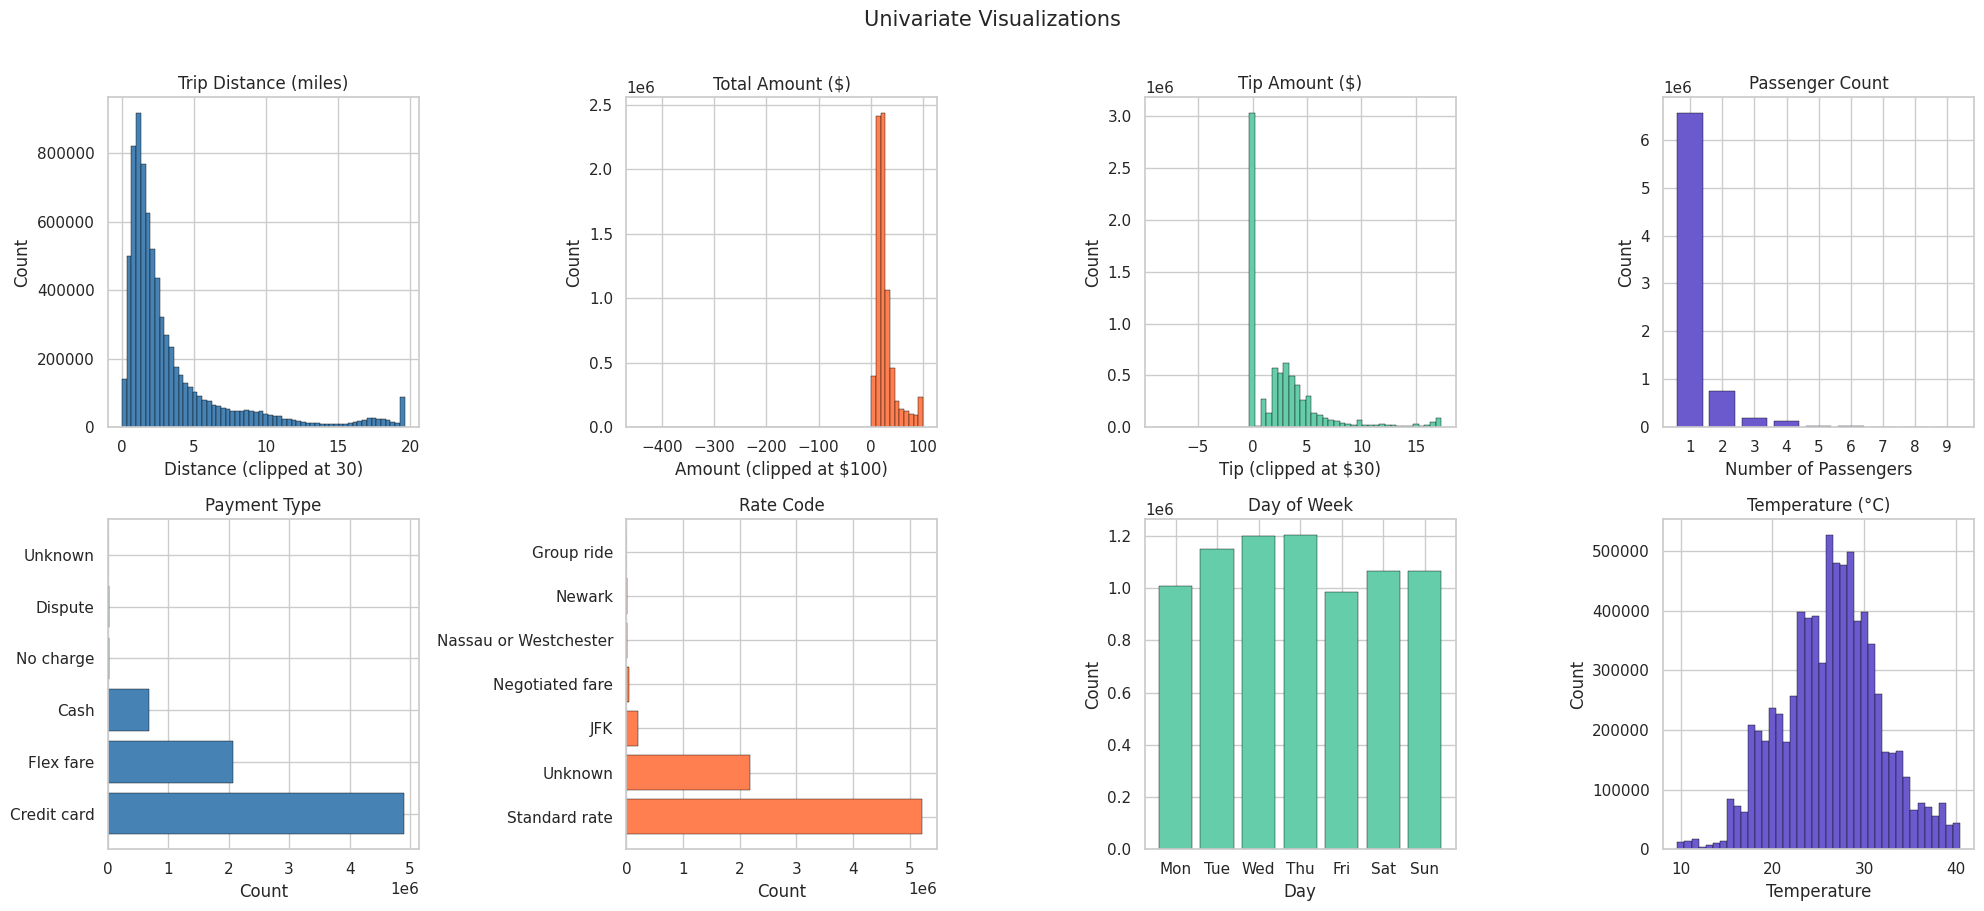

In [ ]:
eda.plot_univariate(taxi_df)


### 4.3. Bivariate Visualizations

The following plots explore relationships between pairs of features:
1. **Trip Distance vs Total Amount** — expected positive linear relationship
2. **Total Amount by Payment Type** — how payment method relates to fare value
3. **Total Amount by Rate Code** — fare differences across rate categories (e.g., airport trips)
4. **Trip Volume by Hour of Day** — demand patterns across the day (higher demands after 17h, lower demands during early mornings).
5. **Trip Distance vs Tip Amount** — longer trips attract higher tips
6. **Temperature vs Average Total Amount** — weather conditions affect fare


<br>

**NOTE:** The visualization is executed on a representative random sample of 10K entries.

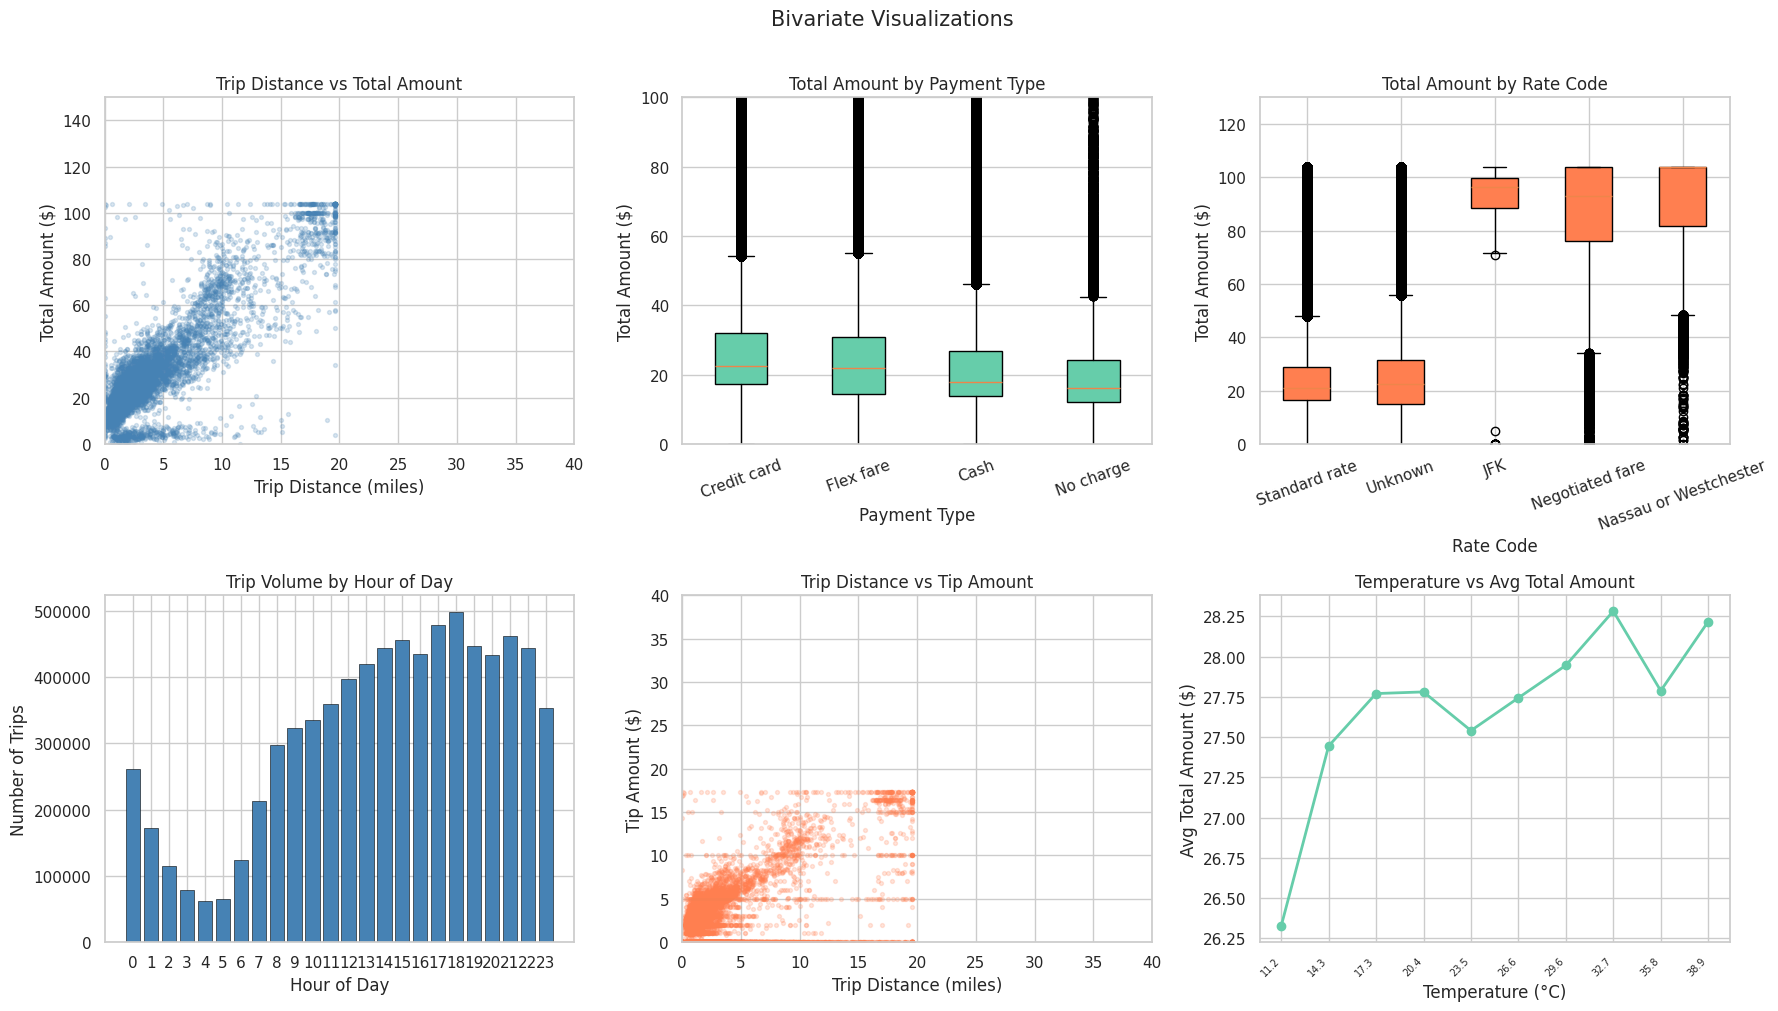

In [ ]:
eda.plot_bivariate(taxi_df)


### 4.4. Correlation Analysis

The heatmap below shows pairwise Pearson correlations between all numerical features. Stronger positive correlations (red) indicate features that tend to increase together, while negative correlations (blue) indicate inverse relationships.

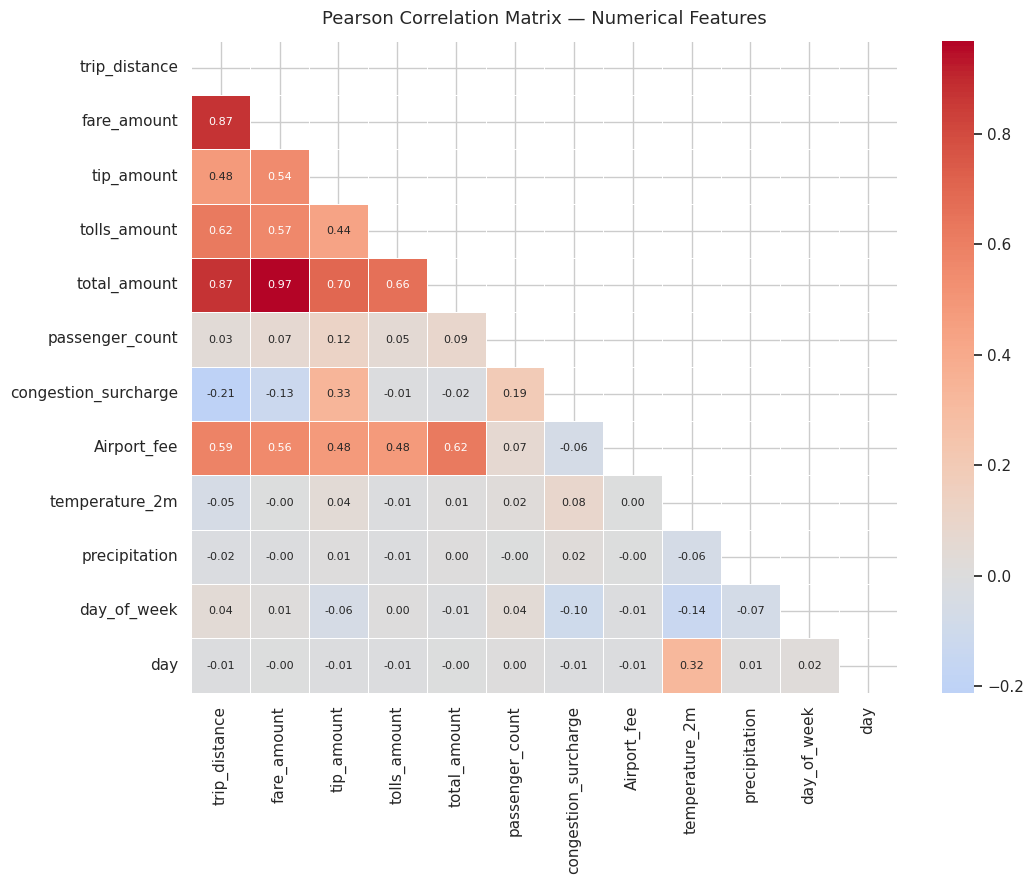

In [ ]:
eda.plot_correlation(taxi_df)


### 4.5. Research Questions

Based on the exploratory analysis above, we formulate the following two research questions:

---

**RQ1 — Supervised Learning:**
> *"Can we classify a high-tipper passenger based on trip-selected features (distance, time of day, day of week, rate code, passenger count) and weather conditions (temperature, precipitation)?"*

- **Type:** Classification
- **Models:** XGBoost and Random Forest
- **Target variable:** `is_high_tip` (Boolean: 1 if tip>20% of the fare amount, 0 otherwise)
- **Features:** `trip_distance`, `pickup_hour` (as hour-of-day), `day_of_week`, `passenger_count`, `temperature_2m`, `precipitation`
- **Motivation:** In Phase 1 Section 5, we are already focusing on training a baseline regression model to predict the continuous variable `fare_amount`. For Supervised Learning in Phase 2, we are moving to a binary classification problem to understand the tipping behaviour of NYC yellow taxi customers. We will transform `tip_amount` feature into a binary feature `is_high_tip` through feature engineering. By using **XGBoost** and **Random Forest**, we will analyze which factors most significantly influence customers tipping behaviour, such as poor weather conditions, late-night trips, weekend travel, etc. This provide valuable insights for optimizing driver service and maximizing incomes.

---

**RQ2 — Unsupervised Learning:**
> *"Can we identify the distinct natural clusters of NYC taxi trips based on their temporal, financial to study customer behavior?"*

- **Type:** Clustering (K-Means)
- **Features:** `trip_distance`, `total_amount`, `tip_amount`, `pickup_hour` (as hour-of-day), `day_of_week`, `passenger_count`, `temperature_2m`, `precipitation`
- **Motivation:** The bivariate and correlation analysis reveal non-uniform distributions and potential sub-populations (e.g., airport trips, short city hops, late-night rides). Clustering will help characterize distinct rider archetypes and trip patterns, which can inform targeted services and policy decisions.

<br>

## 5.Baseline Model
___

We will do a comparison of three Linear Regression models for target feature `fare_amount`:
- **Model A** will use only 1 input: `trip_distance`
- **Model B** will use 2 inputs: `trip_distance` and `tip_amount`
- **Model C** will use 3 inputs: `trip_distance`, `tip_amount` and `Airport_fee`
<br>

We chose `trip_distance` as our main predictive feature because its pearson correlation coefficient with our target `fare_amount` is the highest among features that are not dependant on the target, at 0.87. This shows a strong positive relationship, perfect for linear regression. Our other predictive features, `airport_fee` and `tip_amount`, were chosen because of their non-negligible pearson correlation coefficients of 0.56 and 0.54, respectively. Our goal with those three models is to see if our target is better predicted with `trip_distance` alone, or if it predicts better with the aid of one or two other correlated features.

However, we must first do a bit of additional data wrangling.
- **Reason 1:** Some rows show negative fares, likely due to refunds or system adjustments. We want to keep these records because their other features (like distance and time) are still valid for our general analysis.
- **Reason 2:** To avoid skewing our linear regression model, we filtered out these rows to exclude them from the training data.

As such, before we transfer our data to a numpy array, we will drop all rows that have a negative fare amount.


In [ ]:
# First, create a sample dataframe that takes 10,000 rows from those where is_negative is False
regression_sample_df = taxi_df[taxi_df['is_negative'] == False].sample(n=10000, random_state=1)

# Create numpy arrays for our feature X and target Y
X = regression_sample_df[['trip_distance', 'tip_amount', 'Airport_fee']].to_numpy()
Y= regression_sample_df['fare_amount'].to_numpy()

### 5.1. Splitting Phase

We use the `train_test_split` function twice.
- First split to get a 15 % **Testing set** of the entire dataset (by setting the test dataset's size to 0.15)
- Another split to create a **Validation dataset** and a **Training dataset**. We pulled out 15% Validation of the original data from the remaining 85% of the chunk.

This gives us a 70%/15%/15% split of the data for training, testing and validation.

In [ ]:
# 1. Get the 15% Testing set (by setting test_size=0.15)
x_temp, x_test, y_temp, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)

# 2. Get 15% Validation set from the remaining 85% portion
# Training + Validation = temp = Remaining 85%
valid_ratio = 0.15 / 0.85
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp, test_size=valid_ratio, random_state=1)

# Check
print(f"Train set: {len(x_train)/len(X):.1%}")
print(f"Valid set: {len(x_valid)/len(X):.1%}")
print(f"Test set:  {len(x_test)/len(X):.1%}")


Train set: 70.0%
Valid set: 15.0%
Test set:  15.0%


### 5.2. Training Phase

Now, we train our 3 models.

In [ ]:
# Train model A with only trip_distance as our x feature
modelA = LinearRegression()

# Transform the x array for model A so it is not 1D, but can't use reshape because it demands to much RAM
x_train_A = x_train[:, 0]
x_train_A = x_train_A[:, np.newaxis]
modelA.fit(x_train_A, y_train)

# Train model B with trip_distance and tip_amount
modelB = LinearRegression()
modelB.fit(x_train[:,:2], y_train)

# Train model C with all features
modelC = LinearRegression()
modelC.fit(x_train, y_train)

LinearRegression()

### 5.3. Validation Phase

**Performance metrics:** We will use two metrics: MSE and $R^2$.
- **Mean Squared Errors (MSE)** is the objective function (loss) which measures how far the predictions are from the targeted ones. A good model has the lowest MSE.
- **$R^2$** is a statistical metric to measure how well our model "fits" the data. A good model has the highest $R^2$.

- We compute these two metrics for **models A, B and C** on the **validation set** to **compare model perfomance**.

In [ ]:
# Get the predictions for the models on the validation set
x_valid_A = x_valid[:, 0]
x_valid_A = x_valid_A[:, np.newaxis]
predictA = modelA.predict(x_valid_A)
predictB = modelB.predict(x_valid[:,:2])
predictC = modelC.predict(x_valid)

# Performance metrics for model A
print(f"MSE for model A: {mean_squared_error(y_valid, predictA):.4f}")
print(f"R2 for model A: {modelA.score(x_valid_A, y_valid):.4f}")

# Performance metrics for model B
print(f"\nMSE for model B: {mean_squared_error(y_valid, predictB):.4f}")
print(f"R2 for model B: {modelB.score(x_valid[:,:2], y_valid):.4f}")

# Performance metrics for model C
print(f"\nMSE for model C: {mean_squared_error(y_valid, predictC):.4f}")
print(f"R2 for model C: {modelC.score(x_valid, y_valid):.4f}")


MSE for model A: 29.4493
R2 for model A: 0.8811

MSE for model B: 28.4416
R2 for model B: 0.8852

MSE for model C: 28.5251
R2 for model C: 0.8849


**Model Performance:**
- The three models give very similar Mean Squared Errors (MSE) and $R^2$, with minor differences in the decimals.
- **Model B** has the lowest MSE and the highest $R^2$.
- **Model Selection:** For Phase 1, we selected **Model B** as our baseline model.
  1. It has the lowest MSE and a higher $R^2$.
  2. It provides higher interpretability than model C, while also being more complex and thus giving a better idea of the relationship between features than model A.

### 5.4. Testing Phase

In [ ]:
test_predict = modelB.predict(x_test[:, :2])
print(f"MSE on test for model B: {mean_squared_error(y_test, test_predict):.4f}")
print(f"R2 on test for model B: {modelB.score(x_test[:, :2], y_test):.4f}")

MSE on test for model B: 36.4747
R2 on test for model B: 0.8614


On the test set, model B shows slightly worst MSE and $R^2$ scores to those in the validation, which is most likely due to natural differences in two randomly separated 15% samples of a larger set. This does mean that model B performs slightly worse on the unseen test data.
- This indicates that the combination of `trip_distance` and `tip_amount` gives better predictions for `fare_amount` than other configurations (`trip_distance` alone, or both with `Airport_fee` added).

- We visualize the model using a scatter plot and a regression line: $y = a1x1 +a2x1 + b$
- $a1$, $a2$ represent the coefficients (weights) for $x_1$ = `trip_distance` and $x_2$ = `tip_amount` respectively.
- $b$ represents the intercept (bias).
- Since our model uses **two features for X**, we show their relationship with the target through two 2D plots, each using the x values and the model's coefficient for one of the features.

In [ ]:
# Extract the parameters from baseline model B
b = modelB.intercept_.item()    # Intercept
a1 = modelB.coef_[0].item()     # Weight for trip distance (x1)
a2 = modelB.coef_[1].item()     # Weight for tip amount (x2)

# Display the equation for Model B
print(f"Bias: {b:0.3f}")
print(f"Coefficient a1: {a1:0.3f}")
print(f"Coefficient a2: {a2:0.3f}")
print(f"\nEquation of Linear Regression Model B:\ny = {a1:0.3f} x1 + {a2:0.3f} x2 + {b:0.3f}")

Bias: 7.169
Coefficient a1: 3.359
Coefficient a2: 0.350

Equation of Linear Regression Model B:
y = 3.359 x1 + 0.350 x2 + 7.169


In [ ]:
# Define the trend line equation for Model B
y_pred_test = lambda x1, x2: a1 * x1 + a2 * x2 + b

Now, let's visualize the trend lines for model B.

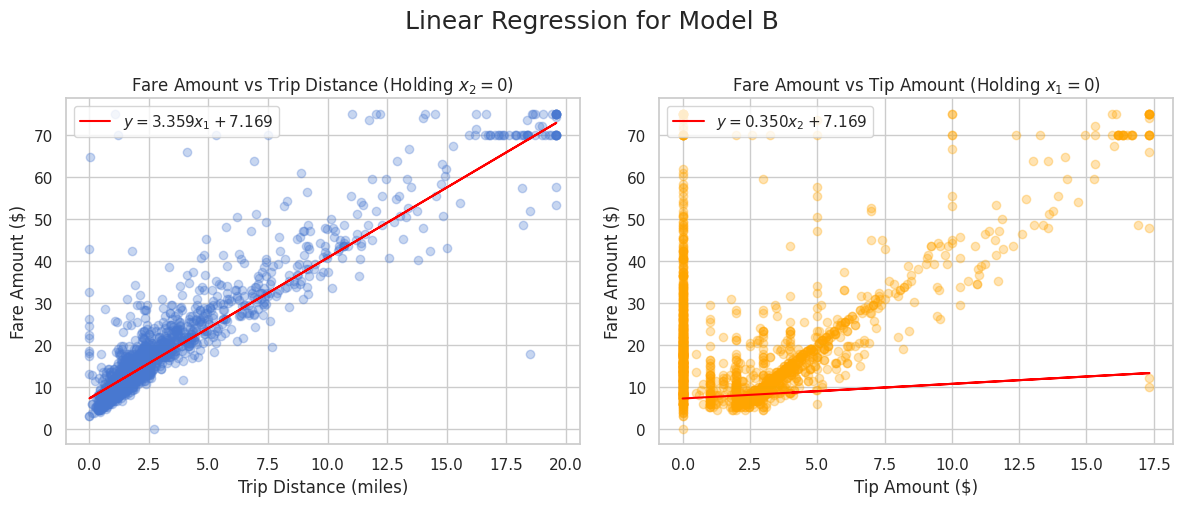

In [ ]:
# Plot the Regression Line for Model B
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Linear Regression for Model B', fontsize=18, y=1.01)

# Fare Amount vs Trip Distance (hold x2 = 0)
x1_test = x_test[:,0]
x2_test = 0
ax[0].scatter(x1_test, y_test, alpha=0.3)
ax[0].plot(x1_test, y_pred_test(x1_test, x2_test), color="red", label = f'$y = {a1:0.3f}x_1 + {b:0.3f}$')
ax[0].set_xlabel('Trip Distance (miles)')
ax[0].set_ylabel('Fare Amount ($)')
ax[0].set_title('Fare Amount vs Trip Distance (Holding $x_2=0$)')
ax[0].legend(loc = 'upper left')

# Fare Amount vs Tip Amount (hold x1 = 0)
x1_test = 0
x2_test = x_test[:,1]
ax[1].scatter(x2_test, y_test, color = 'orange', alpha=0.3)
ax[1].plot(x2_test, y_pred_test(x1_test, x2_test), color="red", label = f'$y = {a2:0.3f}x_2 + {b:0.3f}$')
ax[1].set_xlabel('Tip Amount ($)')
ax[1].set_ylabel('Fare Amount ($)')
ax[1].set_title('Fare Amount vs Tip Amount (Holding $x_1=0$)')
ax[1].legend(loc = 'upper left')

plt.tight_layout()
plt.show();

**Interpretation:**
- The `trip distance` and the `fare amount`'s growths seem to be highly correlated.
- The comparison between `tip amount` and `fare amount` show significantly higher variance.
- The spread of `tip amount` data shows that `tip_amount` is a **weaker predictor** than `trip distance`.
- The high frequency of zero values in the `tip amount` (likely due to cash transactions) motivates a ***further investigation*** into tip distributions across different payment types.
- The trend line for `trip distance` fits the majority of the sample points, suggesting it is the primary driver behind Model B's performance.
- While the `tip amount` trend line appears faulty, its inclusion likely influenced the model, allowing `trip distance` to align more closely with the overall data trend.
- Model B is a useful baseline for `taxi_df`. It confirms that trip distance has a measurable impact on the fare amount.

<br>

## 6.References
___

1. New York City Taxi and Limousine Commission (TLC). (2025). TLC Trip Record Data. https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page [Accessed: Feb. 26 2026]
2. New York City Taxi and Limousine Commission (TLC). (2025). Data Dictionary – Yellow Taxi Trip Records. https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf [Accessed: Feb. 26 2026]
3. Open-Meteo. (2025). Historical Weather API (New York City: June–July 2025). https://open-meteo.com/en/docs/historical-weather-api, [Accessed: Feb. 26 2026]


<br><br>

___
___

# <a name="Phase-2">B.Project Phase 2: Advanced Modeling</a>

### **Task Description**
Phase 2 of this project involves the following steps:
1. Perform feature engineering to optimize model performance.
2. Implement two advanced supervised machine learning classifiers (XGBoost and Random Forest); analyze and compare performance.
3. Implement an unsupervised machine learning model (K-Means) and evaluate its quality.
4. Interpret results to answer the research questions from Section A.

<br><br>

### **Division-of-Labour Statement**
See [Divison-of-Labour](#division-labor) in the header.



<br><br>

### **Restart Session Required**
After completing Phase 1, restart the session (`Runtime` > `Restart Session`) to optimize memory and CPU resources before beginning **Section B: Project Phase 2**.

<br>

## 1.Import Libraries

In [ ]:
# For machine learning models
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, accuracy_score, silhouette_score, confusion_matrix, f1_score, classification_report,
                             roc_curve, davies_bouldin_score, calinski_harabasz_score)

# General libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import gc
import time

**After restarting the session**, let's manually import the cleaned dataset `taxi_cleaned.parquet` to proceed.

**Note**: Please re-run this cell if it throws an error. Temporary file locks may cause an initial failure.

In [ ]:
# Read dataset
time.sleep(2)
taxi_df = pd.read_parquet('taxi_cleaned.parquet')

## 2.Feature Engineering
____
This section involves:
1. Engineering new features to optimize model performance.
2. Performing feature selection.

In [ ]:
# Create a boolean is_high_tip feature based on the percentage of the total amount that is determined by the tip
taxi_df['is_high_tip'] = taxi_df['tip_amount'] >= taxi_df['fare_amount'] * 0.2

# Create fare based and tip based features that are independent of trip distance
taxi_df['log_fare_per_km'] = np.log(np.maximum(taxi_df['fare_amount'], 0) / np.maximum(taxi_df['trip_distance'], 0.5) + 1)
taxi_df['tip_ratio'] = np.log(np.maximum(taxi_df['tip_amount'], 0) / np.maximum(taxi_df ['fare_amount'], 1) + 1)
taxi_df['log_trip_distance'] = np.log(taxi_df ['trip_distance'] + 1)

In [ ]:
# Ensure hour_of_day exists (may be missing if Phase 1 did not complete fully)
if 'hour_of_day' not in taxi_df.columns:
    taxi_df['hour_of_day'] = taxi_df['pickup_hour'].dt.hour.astype('int8')

# Hour of day as a sine/cosine cycle
taxi_df['hour_sin'] = np.sin(2 * np.pi * taxi_df['hour_of_day'] / 24)
taxi_df['hour_cos'] = np.cos(2 * np.pi * taxi_df['hour_of_day'] / 24)

# Day of week as a sine/cosine cycle
taxi_df['day_sin'] = np.sin(2 * np.pi * taxi_df['day_of_week'] / 7)
taxi_df['day_cos'] = np.cos(2 * np.pi * taxi_df['day_of_week'] / 7)


### 2.1. Time-Based & Log Feature
| Feature | Description |
|---------|-------------|
| `is_high_tip` | **Target for RQ1** — `True` if tip ≥ 20 % of base fare (`fare_amount`) |
| `log_trip_distance` | Log-transform of distance to reduce right-skew |
| `log_fare_per_km` | Log-scaled fare efficiency |
| `tip_ratio` | Log-scaled tip-to-fare ratio *(excluded from feature selection — leakage risk)* |

The cell above extends these with **cyclical time encodings**:

| Feature | Description |
|---------|-------------|
| `hour_sin/cos` | Cyclical encoding of hour (23 h stays close to 0 h) |
| `day_sin/cos` | Cyclical encoding of day of week |

### 2.2. Domain-Specific Features

Features derived from NYC taxi domain knowledge:

| Feature | Motivation |
|---------|------------|
| `is_rush_hour` | Weekday 7–9 AM or 5–7 PM — high demand may affect tipping |
| `is_weekend` | Saturday / Sunday ride patterns differ from weekdays |
| `is_night` | 10 PM – 5 AM — night surcharges apply |
| `is_airport` | JFK or Newark flat-rate trip |
| `fare_per_mile` | Cost efficiency of the trip (capped at 99th percentile) |
| `is_credit_card` | Cash tips are **not digitally recorded** → structural zero for cash payments |

In [ ]:
# 1. Rush hour: weekday 7–9 AM or 5–7 PM
taxi_df['is_rush_hour'] = (
    (taxi_df['hour_of_day'].between(7, 9) | taxi_df['hour_of_day'].between(17, 19)) &
    (taxi_df['day_of_week'] < 5)
).astype('int8')

# 2. Weekend
taxi_df['is_weekend'] = (taxi_df['day_of_week'] >= 5).astype('int8')

# 3. Night ride (10 PM – 5 AM)
taxi_df['is_night'] = (
    (taxi_df['hour_of_day'] >= 22) | (taxi_df['hour_of_day'] <= 5)
).astype('int8')

# 4. Airport trip (JFK or Newark flat-rate)
taxi_df['is_airport'] = taxi_df['rate_code'].isin(['JFK', 'Newark']).astype('int8')

# 5. Fare per mile — cap at 99th percentile of positive-fare trips
_cap = (
    taxi_df.loc[taxi_df['fare_amount'] > 0, 'fare_amount'] /
    taxi_df.loc[taxi_df['fare_amount'] > 0, 'trip_distance']
).quantile(0.99)
taxi_df['fare_per_mile'] = (
    (taxi_df['fare_amount'] / taxi_df['trip_distance']).clip(lower=0, upper=_cap)
).astype('float32')
del _cap

# 6. Credit card flag
taxi_df['is_credit_card'] = (taxi_df['payment_type'] == 'Credit card').astype('int8')

print('Domain features added:')
print(taxi_df[['is_rush_hour','is_weekend','is_night',
               'is_airport','fare_per_mile','is_credit_card']].describe().round(3))

Domain features added:
       is_rush_hour   is_weekend     is_night   is_airport  fare_per_mile  \
count   7683628.000  7683628.000  7683628.000  7683628.000    7683628.000   
mean          0.228        0.277        0.202        0.029          7.703   
std           0.419        0.448        0.402        0.167          4.756   
min           0.000        0.000        0.000        0.000          0.000   
25%           0.000        0.000        0.000        0.000          5.221   
50%           0.000        0.000        0.000        0.000          6.940   
75%           0.000        1.000        0.000        0.000          9.028   
max           1.000        1.000        1.000        1.000         37.000   

       is_credit_card  
count     7683628.000  
mean            0.638  
std             0.481  
min             0.000  
25%             0.000  
50%             1.000  
75%             1.000  
max             1.000  


### 2.3. Polynomial & Interaction Features

| Feature | Description |
|--------|-------------|
| **trip_distance_sq** | Distance² — fare grows non-linearly on very long trips |
| **distance_x_passengers** | Distance × passenger count — group trips cost more overall |
| **temp_x_precipitation** | Temperature × precipitation — combined bad-weather effect on tipping |


In [ ]:
taxi_df['trip_distance_sq']       = (taxi_df['trip_distance'] ** 2).astype('float32')
taxi_df['distance_x_passengers']  = (taxi_df['trip_distance'] * taxi_df['passenger_count']).astype('float32')
taxi_df['temp_x_precipitation']   = (taxi_df['temperature_2m'] * taxi_df['precipitation']).astype('float32')

print(f'Polynomial/interaction features added.')
print(f'taxi_df now has {taxi_df.shape[1]} columns total.')

Polynomial/interaction features added.
taxi_df now has 38 columns total.


### 2.4. Feature Selection

We apply three complementary approaches to find the best features for predicting `is_high_tip`:

1. **Filter methods** score features without training a model  
   - Variance threshold: drop near constant features  
   - Pearson correlation: linear relationship with the target  
   - Mutual information: captures non-linear dependencies  
2. **Embedded method** importance scores from a trained Random Forest  
3. **Wrapper method**  Recursive Feature Elimination (RFE) with Logistic Regression  

> **Leakage note:** `tip_amount`, `total_amount`, and `tip_ratio` are excluded  
> they are derived from the same quantity as the target `is_high_tip`.

#### 2.4.1. Setup Feature Matrix & Target

In [ ]:
# All engineered features — leaky columns excluded
FEATURE_COLS = [
    # Raw numerical
    'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount',
    'improvement_surcharge', 'congestion_surcharge', 'Airport_fee',
    'cbd_congestion_fee', 'passenger_count', 'temperature_2m', 'precipitation',
    'hour_of_day', 'day_of_week', 'day',
    # Log / ratio
    'log_trip_distance', 'log_fare_per_km', 'fare_per_mile',
    # Cyclical time
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    # Domain-specific
    'is_rush_hour', 'is_weekend', 'is_night', 'is_airport', 'is_credit_card',
    # Polynomial & interaction
    'trip_distance_sq', 'distance_x_passengers', 'temp_x_precipitation',
]
TARGET = 'is_high_tip'

# Use only positive-fare trips; drop any remaining NaNs
feat_df = taxi_df[taxi_df['is_negative'] == False][FEATURE_COLS + [TARGET]].dropna()

# 50 000-row sample keeps selection fast
sample = feat_df.sample(n=50_000, random_state=42)
X_all  = sample[FEATURE_COLS].values.astype('float32')
y      = sample[TARGET].astype(int).values

print(f'Feature matrix : {X_all.shape[0]:,} samples x {X_all.shape[1]} features')
print(f'Class balance  : is_high_tip = 1  ->  {y.mean()*100:.1f} %')

Feature matrix : 50,000 samples x 30 features
Class balance  : is_high_tip = 1  ->  50.4 %


#### 2.4.2. Filter Methods

Low-variance features removed: ['mta_tax']


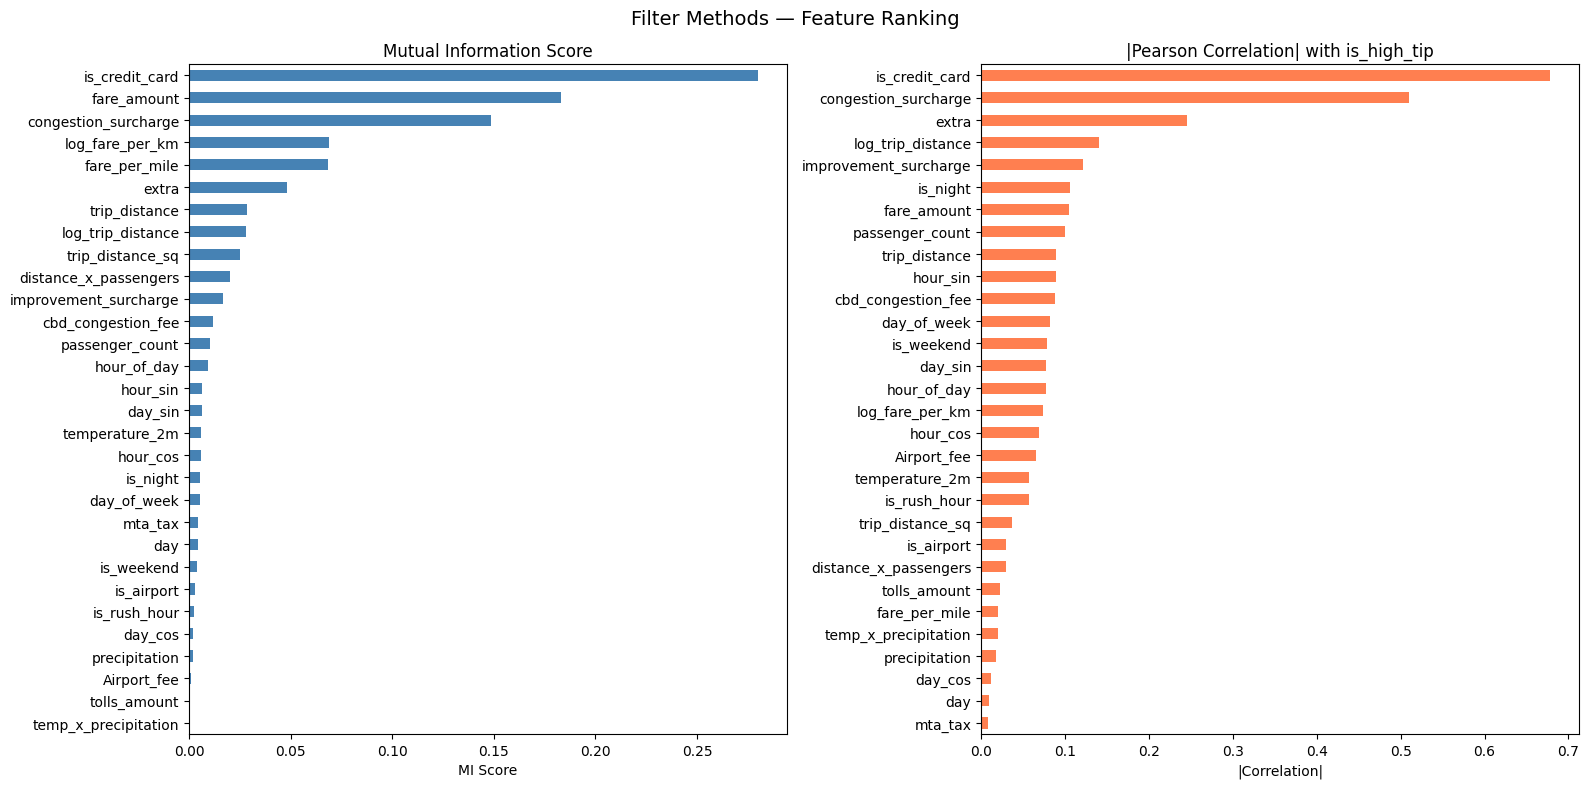

Top 10 — Mutual Information:
is_credit_card           0.2803
fare_amount              0.1832
congestion_surcharge     0.1486
log_fare_per_km          0.0689
fare_per_mile            0.0682
extra                    0.0484
trip_distance            0.0284
log_trip_distance        0.0278
trip_distance_sq         0.0250
distance_x_passengers    0.0199

Top 10 — Pearson Correlation:
is_credit_card           0.6784
congestion_surcharge     0.5095
extra                    0.2450
log_trip_distance        0.1404
improvement_surcharge    0.1218
is_night                 0.1063
fare_amount              0.1050
passenger_count          0.1003
trip_distance            0.0893
hour_sin                 0.0889


In [ ]:
# ── Variance Threshold ──────────────────────────────────────────────────────
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_all)
removed_low_var = [f for f, keep in zip(FEATURE_COLS, vt.get_support()) if not keep]
print(f'Low-variance features removed: {removed_low_var if removed_low_var else "none"}')

# ── Pearson Correlation with Target ──────────────────────────────────────────
corr_target = (
    sample[FEATURE_COLS]
    .corrwith(sample[TARGET].astype(float))
    .abs()
    .fillna(0)   # constant cols produce NaN — treat as 0 correlation
    .sort_values(ascending=False)
)

# ── Mutual Information ────────────────────────────────────────────────────────
mi_scores = mutual_info_classif(X_all, y, random_state=42)
mi_series = pd.Series(mi_scores, index=FEATURE_COLS).sort_values(ascending=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Filter Methods — Feature Ranking', fontsize=14)

mi_series.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Mutual Information Score')
axes[0].set_xlabel('MI Score')

corr_target.plot(kind='barh', ax=axes[1], color='coral')
axes[1].invert_yaxis()
axes[1].set_title('|Pearson Correlation| with is_high_tip')
axes[1].set_xlabel('|Correlation|')

plt.tight_layout()
plt.show()

print('Top 10 — Mutual Information:')
print(mi_series.head(10).round(4).to_string())
print('\nTop 10 — Pearson Correlation:')
print(corr_target.head(10).round(4).to_string())

#### 2.4.3. Embedded Method — Random Forest Feature Importance


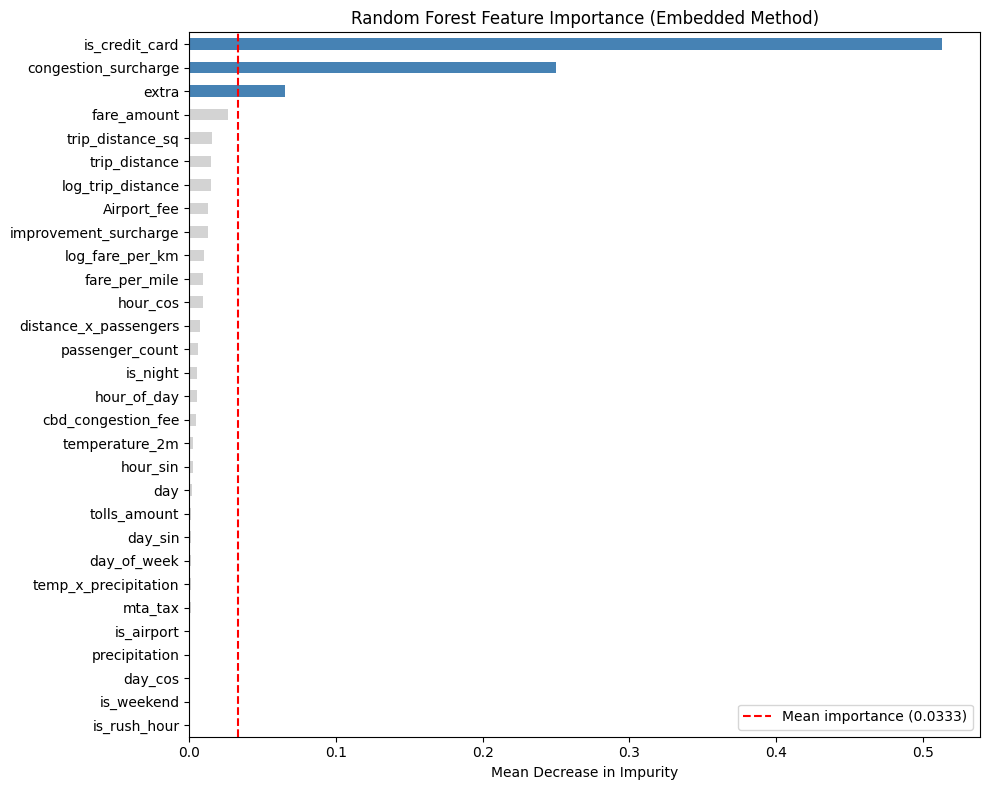

Features at or above mean importance (3): ['is_credit_card', 'congestion_surcharge', 'extra']


In [ ]:
# Train a Random Forest with limited depth to rank features by Gini impurity reduction
rf_selector = RandomForestClassifier(
    n_estimators=100, max_depth=8, random_state=42, n_jobs=-1
)
rf_selector.fit(X_all, y)

# Pair importance scores with feature names and sort descending
rf_importance   = pd.Series(rf_selector.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
mean_importance = rf_importance.mean()

# Color bars: steelblue if at/above mean importance, gray otherwis
colors = ['steelblue' if v >= mean_importance else 'lightgray'
          for v in rf_importance.sort_values().values]

# Plot horizontal bar chart with a vertical mean-importance reference line
fig, ax = plt.subplots(figsize=(10, 8))
rf_importance.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.axvline(mean_importance, color='red', linestyle='--',
           label=f'Mean importance ({mean_importance:.4f})')
ax.set_title('Random Forest Feature Importance (Embedded Method)')
ax.set_xlabel('Mean Decrease in Impurity')
ax.legend()
plt.tight_layout()
plt.show()

# Keep only features at or above mean importance for the next selection step
rf_selected_features = rf_importance[rf_importance >= mean_importance].index.tolist()
print(f'Features at or above mean importance ({len(rf_selected_features)}): {rf_selected_features}')

#### 2.4.4. Wrapper Method  (Recursive Feature Elimination (RFE))

In [ ]:
# Scale features first — Logistic Regression is sensitive to feature magnitude
scaler_rfe = StandardScaler()
X_scaled   = scaler_rfe.fit_transform(X_all)

# RFE iteratively removes the least important features (step=2 at a time)
# until 12 features remain, using Logistic Regression as the base estimator
lr_rfe = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
rfe    = RFE(estimator=lr_rfe, n_features_to_select=12, step=2)
rfe.fit(X_scaled, y)

# Ranking: 1 = selected, higher number = eliminated earlier (least useful)
rfe_ranking  = pd.Series(rfe.ranking_, index=FEATURE_COLS).sort_values()
rfe_selected = rfe_ranking[rfe_ranking == 1].index.tolist()

# Display results
print('RFE Feature Ranking  (1 = selected, higher = eliminated earlier):')
print(rfe_ranking.to_string())
print(f'\nRFE selected {len(rfe_selected)} features: {rfe_selected}')

RFE Feature Ranking  (1 = selected, higher = eliminated earlier):
trip_distance             1
extra                     1
improvement_surcharge     1
tolls_amount              1
congestion_surcharge      1
log_trip_distance         1
hour_of_day               1
log_fare_per_km           1
trip_distance_sq          1
hour_cos                  1
fare_per_mile             1
is_credit_card            1
day_of_week               2
cbd_congestion_fee        2
distance_x_passengers     3
mta_tax                   3
Airport_fee               4
passenger_count           4
is_night                  5
is_rush_hour              5
hour_sin                  6
temperature_2m            6
is_weekend                7
day_sin                   7
fare_amount               8
day                       8
is_airport                9
day_cos                   9
precipitation            10
temp_x_precipitation     10

RFE selected 12 features: ['trip_distance', 'extra', 'improvement_surcharge', 'tolls_amount',

#### 2.4.5. Feature Selection Summary

We combine scores from all three methods into a **composite ranking** and pick the
top 12 features that pass the variance threshold.  
This final set (`FINAL_FEATURES`) will be used by the supervised models in Section 3.

In [ ]:
summary_df = pd.DataFrame({
    'MI_score':      mi_series,
    'Correlation':   corr_target,
    'RF_importance': rf_importance,
    'RFE_rank':      pd.Series(rfe.ranking_, index=FEATURE_COLS),
    'Variance_OK':   pd.Series(dict(zip(FEATURE_COLS, vt.get_support()))),
})

# Normalise each score to 0–1 so they are comparable
for col in ['MI_score', 'Correlation', 'RF_importance']:
    mn, mx = summary_df[col].min(), summary_df[col].max()
    summary_df[col + '_norm'] = (summary_df[col] - mn) / (mx - mn)

summary_df['composite_score'] = (
    summary_df['MI_score_norm'] +
    summary_df['Correlation_norm'] +
    summary_df['RF_importance_norm']
) / 3

summary_df = summary_df.sort_values('composite_score', ascending=False)

print('Feature Selection Summary (sorted by composite score):')
print(summary_df[['MI_score','Correlation','RF_importance',
                   'RFE_rank','Variance_OK','composite_score']].round(4).to_string())

# Final set: top 12 that pass variance threshold
FINAL_FEATURES = (
    summary_df[summary_df['Variance_OK'] == True]
    .head(12)
    .index.tolist()
)
print(f'\nFinal selected features ({len(FINAL_FEATURES)}): {FINAL_FEATURES}')

Feature Selection Summary (sorted by composite score):
                       MI_score  Correlation  RF_importance  RFE_rank  Variance_OK  composite_score
is_credit_card           0.2803       0.6784         0.5133         1         True           1.0000
congestion_surcharge     0.1486       0.5095         0.2502         1         True           0.5884
fare_amount              0.1832       0.1050         0.0262         8         True           0.2826
extra                    0.0484       0.2450         0.0656         1         True           0.2176
log_fare_per_km          0.0689       0.0732         0.0102         1         True           0.1204
log_trip_distance        0.0278       0.1404         0.0148         1         True           0.1080
fare_per_mile            0.0682       0.0207         0.0097         1         True           0.0932
improvement_surcharge    0.0167       0.1218         0.0125         1         True           0.0841
trip_distance            0.0284       0.0893 

### 2.5. Performance Comparison (All Features vs. Selected Features)

We train a **Logistic Regression** classifier on three feature sets and compare
AUC-ROC and Accuracy on a held-out 20 % validation split.

| Feature set | Description |
|-------------|-------------|
| All features (30) | Every engineered feature |
| RF selected | Features with above-mean Random Forest importance |
| Composite selected (top 12) | Top 12 by combined filter + embedded score |

> Logistic Regression is used here as a fast, interpretable baseline.  
> The full Random Forest and XGBoost models in Section 3 will train on `FINAL_FEATURES`.

                Feature Set  n_features  AUC-ROC  Accuracy
          All features (30)          30   0.8648    0.8373
                RF-selected           3   0.8445    0.8251
Composite-selected (top 12)          12   0.8627    0.8384


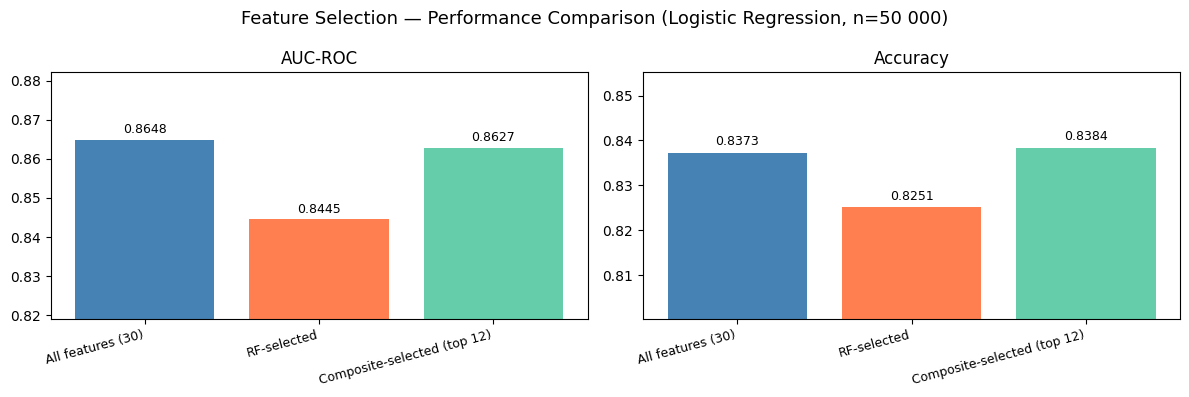

13590

In [ ]:
# Split into train/validation to evaluate feature subsets fairly
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

def evaluate_set(label, indices):
    """Train Logistic Regression on a feature subset and return AUC + Accuracy."""
    Xtr = X_train[:, indices]
    Xv  = X_val[:, indices]
    sc  = StandardScaler()
    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(sc.fit_transform(Xtr), y_train)
    preds  = clf.predict(sc.transform(Xv))
    probas = clf.predict_proba(sc.transform(Xv))[:, 1]
    return {
        'Feature Set': label,
        'n_features' : len(indices),
        'AUC-ROC'    : round(roc_auc_score(y_val, probas), 4),
        'Accuracy'   : round(accuracy_score(y_val, preds), 4),
    }


# Get column indices for each feature subset to pass into evaluate_set
all_idx   = list(range(len(FEATURE_COLS)))
rf_idx    = [FEATURE_COLS.index(f) for f in rf_selected_features]
final_idx = [FEATURE_COLS.index(f) for f in FINAL_FEATURES]

results_df = pd.DataFrame([
    evaluate_set('All features (30)',          all_idx),
    evaluate_set('RF-selected',                rf_idx),
    evaluate_set('Composite-selected (top 12)', final_idx),
])

print(results_df.to_string(index=False))

# Plot Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Feature Selection — Performance Comparison (Logistic Regression, n=50 000)', fontsize=13)
palette = ['steelblue', 'coral', 'mediumaquamarine']
for i, metric in enumerate(['AUC-ROC', 'Accuracy']):
    axes[i].bar(results_df['Feature Set'], results_df[metric], color=palette)
    axes[i].set_title(metric)
    lo = results_df[metric].min()
    axes[i].set_ylim(max(lo * 0.97, 0), min(results_df[metric].max() * 1.02, 1.0))
    axes[i].set_xticks(range(len(results_df)))
    axes[i].set_xticklabels(results_df['Feature Set'], rotation=15, ha='right', fontsize=9)
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Free memory
del feat_df, sample, X_all, y, X_train, X_val, y_train, y_val, X_scaled
del vt, rf_selector, rfe, scaler_rfe, lr_rfe
gc.collect()


<br>

## 3.Advanced Supervised Learning
___
This section involves training 2 advanced classifcation models: **Random Forest** and **XGBoost**.

The tasks involve the following tasks:
1. Check label distribution
2. Define the feaures X and the target variable y
3. Split dataset into training, validation and test sets
4. Tune the hyperparameters
5. Train the tuned models
6. Evaluate and compare the models' performance on test set

**RQ1 — Supervised Learning:**
> *"Can we classify a high-tipper passenger based on trip-selected features (distance, time of day, day of week, rate code, passenger count) and weather conditions (temperature, precipitation)?"*

- **Model Type:** Classification
- **Models:** Random Forest and XGBoost
- **Target variable:** `is_high_tip`

### 3.1. Check label distribution
The dataset contains **significant class imbalance** for both `payment method` and the target variable `is_high_tip`.
- Tips are primarly recorded for `Credit card` transactions.
- When a customer pays with `Cash`, tips are not recorded in the system, which sets `is_high_tip` to **False** systematically. This violates data integrity.
- The same systematic problem applies to other payment methods.

In [ ]:
# Show the class imbalance
(taxi_df.groupby('payment_type', observed=False)['is_high_tip'].value_counts(normalize=True)*100).round(1).astype(str) + '%'

payment_type  is_high_tip
Cash          False          100.0%
              True             0.0%
Credit card   True            74.5%
              False           25.5%
Dispute       False           93.8%
              True             6.2%
Flex fare     False           80.4%
              True            19.6%
No charge     False           98.0%
              True             2.0%
Unknown       False          100.0%
              True             0.0%
Name: proportion, dtype: object

The following plot (in logarithmic scale) shows that the majority of customers pay with `Credit card`, illustrating a significant class imbalance in `Payment Type`.

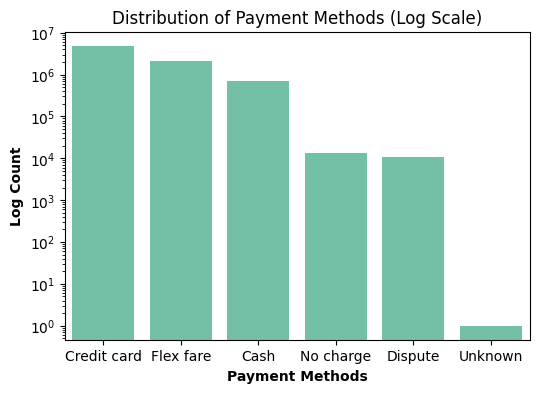

In [ ]:
# Plot with a Log Scale to see the Payment Methods Distribution
pay_counts = taxi_df['payment_type'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=pay_counts.index, y=pay_counts.values, color='MediumAquamarine', order=pay_counts.index)
ax.set_yscale("log")

# Set titel and labels
plt.title('Distribution of Payment Methods (Log Scale)')
plt.ylabel('Log Count', fontweight='bold')
plt.xlabel('Payment Methods', fontweight='bold')
plt.show();

For data integrity, we need to keep records with `Credit card` transactions only.

`Low Tip` (False) is a **label noise** since people who tipped in cash or with other payment methods were recorded as $0.

In [ ]:
# Filter out records with credit card transactions only
credit_card_df = taxi_df[taxi_df['payment_type']=='Credit card']

# Show label distribution
tip_distribution = credit_card_df['is_high_tip'].value_counts(normalize=True).to_frame()
tip_distribution['percentage'] = (tip_distribution['proportion'] * 100).round(2).astype(str) + '%'
tip_distribution.index = ['High Tipper (>=20%)', 'Low/Mid Tipper (<20%)']
display(tip_distribution)

,proportion,percentage
High Tipper (>=20%),0.744679,74.47%
Low/Mid Tipper (<20%),0.255321,25.53%


However, the filtered dataset `credit_card_df` still contains significant class imbalance among the tippers (74/25).

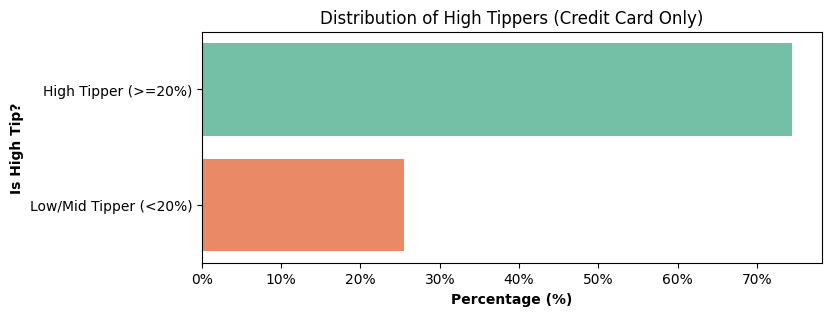

22582

In [ ]:
# Plot the tipper label imbalance
fig, ax = plt.subplots(figsize=(8, 3))
sns.barplot(
    x=tip_distribution['proportion'],
    y=tip_distribution.index.astype(str),
    hue=tip_distribution.index.astype(str),
    palette=['MediumAquamarine', 'Coral'],
    legend=False,
    ax=ax
)

# Set title and labels
plt.title('Distribution of High Tippers (Credit Card Only)')
plt.xlabel('Percentage (%)', fontweight='bold')
plt.ylabel('Is High Tip?', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show();

# Free up memory
del pay_counts, tip_distribution
gc.collect()

Before modelling the dataset, we need to remove the records with negative amount(s) in `credit_card_df` (which contains 1 row).

In [ ]:
# Find records with negative fares
display(credit_card_df.loc[credit_card_df['is_negative']])

# Remove records with negative fares
credit_card_df = credit_card_df.loc[~credit_card_df['is_negative']]

,passenger_count,trip_distance,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,...,day_cos,is_rush_hour,is_weekend,is_night,is_airport,fare_per_mile,is_credit_card,trip_distance_sq,distance_x_passengers,temp_x_precipitation
2236012,1,3.47,Credit card,-19.1,-2.5,-0.5,5.27,0.0,-1.0,-21.08,...,1.0,1,0,0,0,0.0,1,12.0409,3.47,0.0


To address the imbalanced dataset, we must use the following tools:
- **Data Preparation**: Stratified K-Fold CV
- **Performance Metrics**: F1-score, ROC-AUC metrics, Confusion Matrix, Classification Report

### 3.2. Create samples

A representative random sample of **1 millions record**s are extracted from the dataset to optimize computational efficiency. **Stratification** is used to preserve the original class ratio.

Following the analysis in Section 2, we will use the `FINAL_FEATURES` list. Because the data is limited to credit card transactions, the `is_credit_card` feature at index 0 is redundant and will be removed.

In [ ]:
# Sample 1 million records from the initial dataset
sample_df, _ = train_test_split(
    credit_card_df,
    train_size=1_000_000,                       # extract 1M rows randomly
    stratify=credit_card_df['is_high_tip'],     # preserve original class ratio
    random_state=42                             # for reproducibility
)

# Define variable X, y
X = sample_df[FINAL_FEATURES[1:]]       # Use FINAL_FEATURES
y = sample_df['is_high_tip']

# Inspect the number of rows and columns to train
print(f"X shape: {X.shape}")

X shape: (1000000, 11)


### 3.3. Split dataset

The dataset is splitted into 70%/15%/15%.

In [ ]:
# 1. Get the 15% Testing set (by setting test_size=0.15)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=1)

# 2. Get 15% Validation set from the remaining 85% portion
# Training + Validation = temp = Remaining 85%
valid_ratio = 0.15 / 0.85
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=valid_ratio, random_state=1)

# Check
print(f"Train set: {len(X_train)/len(X):.1%}")
print(f"Valid set: {len(X_valid)/len(X):.1%}")
print(f"Test set:  {len(X_test)/len(X):.1%}")

Train set: 70.0%
Valid set: 15.0%
Test set:  15.0%


### 3.4. Tune Hyperparameters

We used **RandomSearchCV** instead of GridSearchCV for tuning the hyperparameters because of its effective and faster performance. Instead of searching all the combinations of parameters in the search space, RandomSearchCV uses mathematical computations to find the optimal configurations for the next iteration. We tuned the hyperparameters for both Random Forest and XGBoost on the **validation set**.
- The performance metric for tuning is **F1-Score**.
- To preserve original class ratio, we used Stratification.

> **NOTE**: Running the code below will take around **10 minutes.**

In [ ]:
# ── STEP 1: Define the search space for each model ────────────────────────────

# Random Forest Search Space
rf_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15],              # to avoid overfitting
    'min_samples_leaf': [50, 100],
    'max_samples': [0.1, 0.2]           # Trains each tree on only 10-20% of the 1M rows
}

# XGBoost Search Space
xgb_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],             # to avoid overfitting
    'learning_rate': [0.01, 0.1]
}


# ── STEP 2: Define the models ─────────────────────────────────────────────────
models = {
    'RandomForest': (RandomForestClassifier(
        class_weight=None,
        random_state=42,
        n_jobs=-1
    ), rf_grid),

    'XGBoost': (XGBClassifier(
        tree_method='hist',
        scale_pos_weight=1,           # let StratifiedKFold to handle class imbalance
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',        # criterion for binary classification
        random_state=42
    ), xgb_grid)
}


# ── STEP 3: Tune the hyperparameters with RandomizedSearchCV ──────────────────

# Apply Stratification to preserve original class ratio
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Tune the hyperparameters
hparams_results = []
for name, (model, search_grid) in models.items():
    start_time = time.time()

    # Search for best parameters
    search = RandomizedSearchCV(model, search_grid, n_iter=5, cv=cv, scoring='f1', n_jobs=-1, random_state=42)
    search.fit(X_train, y_train)

    elapsed_time = time.time() - start_time

    # Evaluate on validation set
    y_pred = search.predict(X_valid)
    f1 = f1_score(y_valid, y_pred)

    # Append results to the list
    hparams_results.append({
        'model': name,                                # model name
        'cv_f1_mean': round(search.best_score_, 4),
        'valid_f1_score': round(f1, 4),
        'train_time': round(elapsed_time, 2),         # time elapsed for training
        'best_params': search.best_params_,           # best hyperparameters
        'feature_importances': list(search.best_estimator_.feature_importances_)
    })
    print(f"Elapsed time for {name}: {elapsed_time:.2f}s")


# ── STEP 4: Display the Comparison Table ─────────────────────────────────────
print("\n--- Model Comparison ---")
hparams_df = pd.DataFrame(hparams_results)
display(hparams_df[['model', 'cv_f1_mean', 'valid_f1_score', 'train_time']])

Elapsed time for RandomForest: 341.96s
Elapsed time for XGBoost: 149.70s

--- Model Comparison ---


,model,cv_f1_mean,valid_f1_score,train_time
0,RandomForest,0.8637,0.8636,341.96
1,XGBoost,0.8637,0.8635,149.70


**Interpretation**:
- F1-score is a reliable performance metric for imbalanced dataset. This harmonic mean balances between Precision and Recall.
- Both models have good and identical F1-scores, showing that they classify labels mostly correctly (86%) on both training and validation sets.
- Identical F1-scores across 3-fold CV (`cv_f1_mean = 0.8637`) and the unseen validation sets (`valid_f1_score = 0.8636`) indicate that both models are stable and show no significant overfitting.
- XGBoost has a significant faster speed for training than Random Forest.

**Result**: Here are the best hyperparameters found by RandomSearchCV.

In [ ]:
# Extract the best hyperparameters
rf_params = hparams_results[0]['best_params']
xgb_params = hparams_results[1]['best_params']

# Display the hyperparameters
print(f"Best Hyperarameters (Random Forest): {rf_params}")
print(f"Best Hyperarameters (XGBoost): {xgb_params}")

Best Hyperarameters (Random Forest): {'n_estimators': 100, 'min_samples_leaf': 50, 'max_samples': 0.2, 'max_depth': 15}
Best Hyperarameters (XGBoost): {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}


### 3.5. Training Phase
Both Random Forest and XGBoost models are retrained on the training set using their respective best-performing hyperparameters.

In [ ]:
# Initialize the tuned Random Forest model
rf = RandomForestClassifier(
    **rf_params,
    class_weight=None,
    random_state=42,
    n_jobs=-1)

# Initialize the tuned XGBoost model
xgb = XGBClassifier(
    **xgb_params,
    early_stopping_rounds=10,
    tree_method='hist',
    scale_pos_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42)

# Train both models
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

### 3.6. Model Evaluation and Comparison

A final evalution is conducted on the tuned models with the held-out test set.
The performance metrics are:
1. Confusion Matrix
2. Classification Report
3. ROC-AUC

In [ ]:
# Compute the predictions on the test set
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

#### 3.6.1. Confusion Matrix

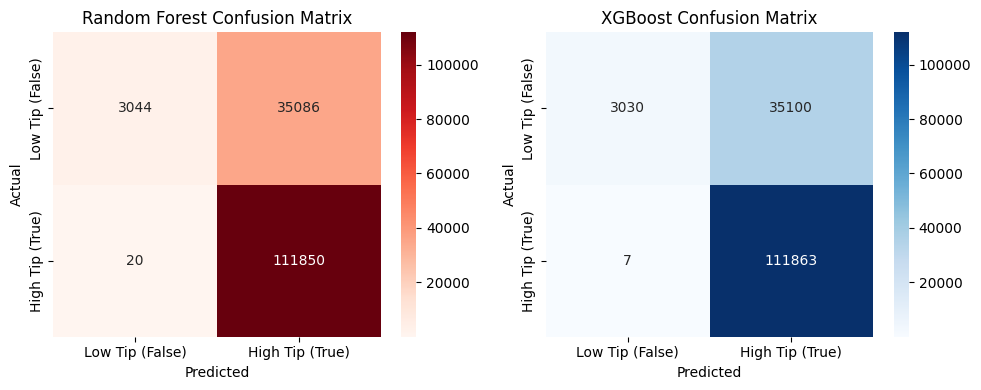

In [ ]:
# Generate the confusion matrices
labels = ['Low Tip (False)', 'High Tip (True)']
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', ax=ax1,
            xticklabels=labels, yticklabels=labels)
ax1.set_title('Random Forest Confusion Matrix')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

# Plot XGBoost
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=labels, yticklabels=labels)
ax2.set_title('XGBoost Confusion Matrix')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

**Interpretation:**
- Both models show nearly identical confusion matrices, indicating **performance convergence**.
- Since both Random Forest (Bagging) and XGBoost (Boosting) are built upon Decision Tree ensembles (same foundation basis), it is expected that they converge on similar performance scores when provided with the same feature set.
- Both models correctly classify most of `High Tip` (True) as `High Tip` (True) labels.
- Both confusion matrices reveal a **consistent error pattern**: `Low Tip` (False) data are frequently misclassified as `High Tip` (True).
- This indicates that both models fail to distinguish `Low Tip` records from `High Tip` records. The dataset is clearly biased towards high tippers.
- **XGBoost** is slightly more performant, recording 13 fewer False Negatives (7 vs 20) than Random Forest.
- **Model Selection**: While the difference between the two models is minimal (varying by only a few counts), **XGBoost** is the selected model. It captures the `High Tip` (True) class more accurately.

#### 3.6.2. Classification Report

In [ ]:
# Generate classification report for each model
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

# Extract each metrics from the reports
reports = {'RandomForest': report_rf, 'XGBoost': report_xgb}

# 2. Build the merged reports
merged_reports = []
for name, report in reports.items():
    merged_reports.append({
        "Model": name,
        "Accuracy": report['accuracy'],
        "Macro F1": report['macro avg']['f1-score'],
        "Weighted F1": report['weighted avg']['f1-score'],
        "Recall (False)": report['False']['recall'],
        "Precision (True)": report['True']['precision']
    })

# Display classification report
print("\n--- Classification Report: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- Classification Report: XGBOOST ---")
print(classification_report(y_test, y_pred_xgb))


--- Classification Report: RANDOM FOREST ---
              precision    recall  f1-score   support

       False       0.99      0.08      0.15     38130
        True       0.76      1.00      0.86    111870

    accuracy                           0.77    150000
   macro avg       0.88      0.54      0.51    150000
weighted avg       0.82      0.77      0.68    150000


--- Classification Report: XGBOOST ---
              precision    recall  f1-score   support

       False       1.00      0.08      0.15     38130
        True       0.76      1.00      0.86    111870

    accuracy                           0.77    150000
   macro avg       0.88      0.54      0.51    150000
weighted avg       0.82      0.77      0.68    150000



In [ ]:
# Display the classification reports into a DataFrame (with more decimals)
pd.DataFrame(merged_reports)

,Model,Accuracy,Macro F1,Weighted F1,Recall (False),Precision (True)
0,RandomForest,0.765960,0.506071,0.682203,0.079832,0.761216
1,XGBoost,0.765953,0.505785,0.682062,0.079465,0.761164


**Intepretation:**
- **Performance Convergence**: Both models show identical classification reports. Both models are based on Decision Tree and reached the predictive power limit on the same set of feature.
- **High Recall (1.00)**: Both models successfully identify almost all `High Tip` (True) records.
- **Moderate Precision (0.76)**: Both models have a moderate precision. The `Low Tip` (False) are frequently misclassified as `High Tip` (True).
- **Low Recall (Low Tip)**: Both models fail to accurately classify `Low Tip` (False). Both models ignore False labels with a poor recall of 0.08.
- **Accuracy**: An accuracy of 0.77 is misleading due to the 75/25 class imbalance.
- **Low Macro F1**: This low metric indicates that both models fail to classify the minority class `Low Tip` (False). Both models fail to distinguish between the two classes effectively.
- **Model Selection**: The classification reports show a tie. We need further performance metrics to compare models.

#### 3.6.3. ROC-AUC

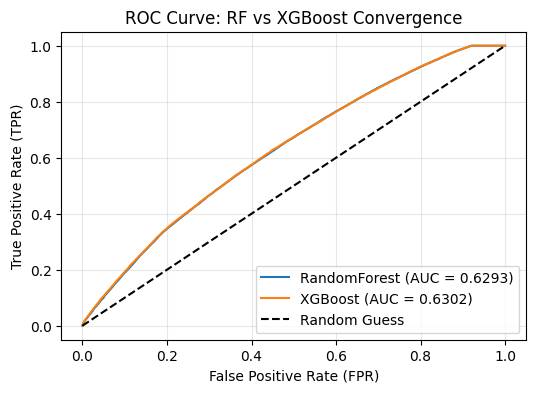

In [ ]:
# Define the models
models = {'RandomForest': rf,
          'XGBoost': xgb}

# Compute and plot the ROC-AUC
plt.figure(figsize=(6, 4))
auc_scores = []
for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc = roc_auc_score(y_test, y_probs)
    auc_scores.append({
        "Model": name,
        "AUC": auc})

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

# Plot the diagonal 50/50 line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve: RF vs XGBoost Convergence')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

**Intepretation:**
- **Performance Convergence**: Both models show nearly identical AUC scores, indicating that both models reached similar predictive power limit on this feature set.
- **Random Forest's AUC Score**: around 0.6293.
- **XGBoost's AUC Score**: around 0.6302 (a sligthly higher score).
- Both AUC scores are moderate, showing that they struggle to distinguish between two classes (`High Tip` vs `Low Tip`).
- Both ROC curves lean toward the y-axis (True Positive Rate), confirming that both models are effective at identifying nearly all `High Tip` (True) class.
- Both ROC-AUC curves overlap, indicating that both models are equally limited by the features provided.
- **Model Selection**: Since XGBoost performs slightler better than Random Forest, **XGBoost** is selected as the best-performing model.

#### 3.6.4. Feature Importance

In this section, we inspect which features influence the most in each model during training phase: Random Forest and XGBoost. This enables to **investigate** whether they behave differently on the same set of features.

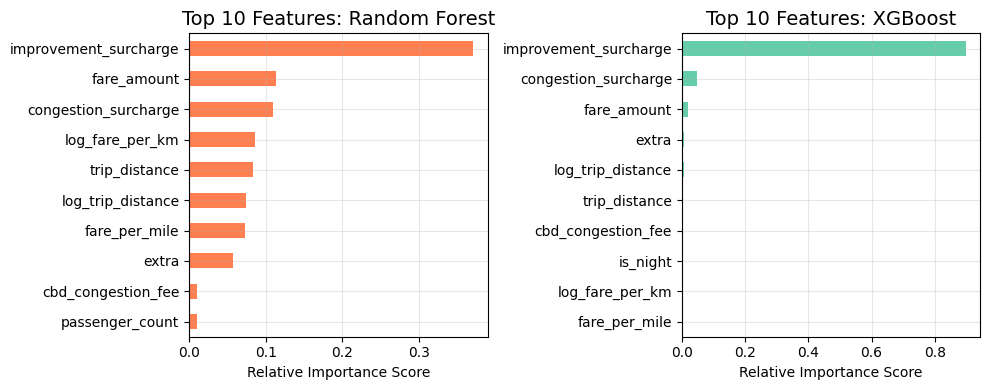

In [ ]:
# Extract the scores for each model from the list
rf_scores = [res['feature_importances'] for res in hparams_results if res['model'] == 'RandomForest'][0]
xgb_scores = [res['feature_importances'] for res in hparams_results if res['model'] == 'XGBoost'][0]


# Plot for Random Forest
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(rf_scores, index=X_train.columns).sort_values().tail(10).plot(
    kind='barh', ax=ax1, color='Coral'
)
ax1.set_title("Top 10 Features: Random Forest", fontsize=14)
ax1.set_xlabel("Relative Importance Score")
ax1.grid(alpha=0.3)

# Plot for XGBoost
pd.Series(xgb_scores, index=X_train.columns).sort_values().tail(10).plot(
    kind='barh', ax=ax2, color='MediumAquamarine'
)
ax2.set_title("Top 10 Features: XGBoost", fontsize=14)
ax2.set_xlabel("Relative Importance Score")

ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation**:
- Even if Random Forest and XGBoost provide the nearly identical performance scores, the plots above confirm that the models prioritize features differently.
- For both models, the primary predictor is `improvement_surcharge`, confirming the performance convergence.
- **Random Forest** gives more distributed importance across secondary features: `fare_amount` and `congestion_surcharge`.
- **XGBoost** puts little/none additional value in other features, making a sparse distribution. It concentrates all the weight on one single feature: `improvement_surcharge`.
- Because both models prioritize the same top three features (`improvement_surcharge`, `fare_amount` and `congestion_surcharge`), it explains why they achieve nearly identical performance metrics. This convergence suggests that both models successfully identify the same primary drivers of tipping behavior, regardless of their different algorithmic approaches (Bagging vs. Boosting).

<br>

### 3.7. Model Selection

In [ ]:
# Extract all metrics and create a comparion table
comparison_table = []
for hparam, auc, report in zip(hparams_results, auc_scores, merged_reports):
    model = hparam['model']
    if model == auc['Model'] and model == report['Model']:
      # Extract Metrics
      row = {
            'Model': model,
            'Train Time (sec)': hparam['train_time'],
            'CV F1': round(hparam['cv_f1_mean'], 4),            # internal metric (validation set)
            'Valid F1': round(hparam['valid_f1_score'], 4),     # internal metric (validation set)
            'Macro F1': round(report['Macro F1'], 4),
            'Recall (False)': round(report['Recall (False)'], 4),
            'Precision (True)': round(report['Precision (True)'], 4),
            'AUC': round(auc['AUC'], 4)}
      # Append to the table
      comparison_table.append(row)


# Display model comparison table
pd.DataFrame(comparison_table)

,Model,Train Time (sec),CV F1,Valid F1,Macro F1,Recall (False),Precision (True),AUC
0,RandomForest,341.96,0.8637,0.8636,0.5061,0.0798,0.7612,0.6293
1,XGBoost,149.70,0.8637,0.8635,0.5058,0.0795,0.7612,0.6302


**Internal Metrics**

Both models achieved identical F1-scores (around 0.86) across 3-fold CV (`CV F1`) and the unseen validation sets (`Valid F1`), indicating stable performance and a lack of overfitting. The consistency between training and validation suggests the models have successfully generalized data patterns.

<br>

**External Metrics on the held-out Test set:**

Both Randon Forest and XGBoost have nearly identical performance metrics on the unseen held-out test set across the confusion matrix, confusion reports and ROC-AUC scores.

<br>

**Model Selection**

**XGBoost** is selected as the **best model** for this specific 1,000,000-record binary classification problem for the following reasons:

- **Accuracy**: It identifies the `High Tip` (True) class more accurately in the confusion matrix.
- **Predictive Power**: It achieves a slightly higher AUC score (0.6302).
- **Efficiency**: It performs **significantly faster** than Random Forest, with a training time of ~150s compared to ~250s.
- **Optimized Architecture**: As a sequential ensemble, XGBoost effectively corrects the residual errors from previous trees, ensuring an optimized performance.


<br>

**Limitations**:

Even after filtering and random sampling, the dataset remains **imbalanced**. This persistent imbalance causes the model to struggle with classification. For future works, undersampling the majority class or implementing Synthetic Minority Over-sampling Technique (SMOTE) should be considered to create a more balanced training set to improve the performance metrics.

In [ ]:
# Free up memory
del (credit_card_df, sample_df,
     X, y, X_temp, X_test, y_temp, y_test, X_train, X_valid, y_train, y_valid,
     rf_grid, xgb_grid, models, cv, fig,
     hparams_results, rf_params, xgb_params, rf, xgb, y_pred_rf, y_pred_xgb,
     cm_rf, cm_xgb, report_rf, report_xgb, merged_reports, auc_scores, rf_scores, xgb_scores, comparison_table)

%reset -f out
gc.collect()

Flushing output cache (6 entries)


0

<br>

## 4.Unsupervised Learning
___
Our unsupervised learning model will be a K-Means clustering model based on the research question:

**RQ2 — Unsupervised Learning:**
> *"Can we identify the distinct natural clusters of NYC taxi trips based on their temporal, financial to study customer behavior?"*

<br>

- **Models**: PCA, K-Means
- **Features used**: `log_trip_distance`, `log_fare_per_km`, `tip_ratio`, `hour_of_day`, `day_of_week`, `passenger_count`, `temperature_2m` and `precipitation`.

<br>

`log_trip_distance`, `log_fare_per_km` and `tip_ratio` are transformations of the features `trip_distance`, `fare_amount` and `tip_amount`. Because of their range and variance, and their interconnectedness, these features would have too much weight in a distance based model, especially for K-Means. By using the properties of **logarithms** and by **decoupling** both the fare from the distance and the tip from the fare, our features are more equal in influence.

<br>

The tasks involve the following:

1. Select our features
2. Create a subsample of 10k for the purpose of finding the best value of the hyperparameter K
3. Scale the features using sklearn's RobustScaler
4. Apply PCA to get principal components.

We will then look at the explained variance ratio of the components, and keep the components that explain at least 90% of the variance, starting with the first which explain the most variance, and going from there.

In [ ]:
# Create a subsample of 10K rows
mask = taxi_df['fare_amount'] >= 0
cluster_df = taxi_df.loc[mask, ['log_trip_distance', 'log_fare_per_km', 'tip_ratio', 'hour_of_day', 'day_of_week', 'passenger_count', 'temperature_2m', 'precipitation']]
training_sample = cluster_df.sample(n=100000, random_state=1)

# Normalize X
scaler = RobustScaler()
sample_X = scaler.fit_transform(training_sample)

# Compute PCA
pca = PCA(random_state=1)
principal_components = pca.fit_transform(sample_X)
pca.explained_variance_ratio_

array([0.3212831 , 0.16968578, 0.13091551, 0.10989789, 0.10051379,
       0.07004664, 0.05764836, 0.04000892], dtype=float32)

**Observation**: We can see from the result that the first 6 components explain around 90% of the variance. We will keep them for our model.

### 4.1. Elbow method

The next step is to find the best value of K. For this purpose, we will use the elbow method, calculating the inertia of the MiniBatchKMeans model at each value of K in our chosen range of candidate K, from 2 to 20.

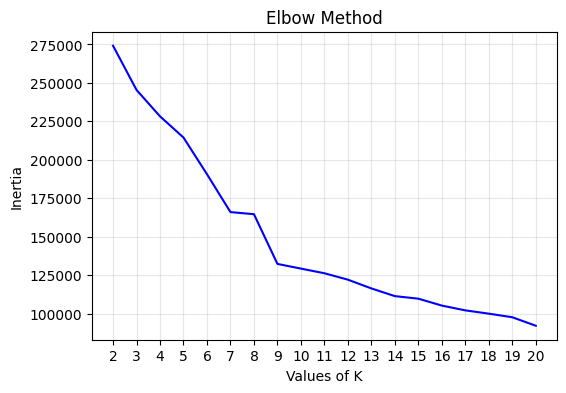

In [ ]:
# Compute inertia
inertia_history = []
for k in range(2, 21):
  kmeans_model = MiniBatchKMeans(n_clusters=k, random_state=1, batch_size=5000).fit(principal_components[:,:6])
  inertia_history.append(kmeans_model.inertia_)

# Clean variables that will not be used anymore
del training_sample, sample_X, mask
gc.collect()

# Plot the elbow method graph
plt.figure(figsize=(6,4))
plt.plot(np.arange(2, len(inertia_history) + 2), inertia_history, color='blue')
plt.xticks(range(2, len(inertia_history) + 2))
plt.xlabel('Values of K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(alpha=0.3)
plt.show()

**Observation:** From the graph, we can see that the "elbow" starts at k = 7. After that, the trend is clearly towards a lower slope of inertia.

### 4.2. PCA

Now that we have our value for our hyperparameter K, we will use PCA on our full dataset and train our final MiniBatchKMeans model.

In [ ]:
# Apply PCA
X = scaler.fit_transform(cluster_df)
principal_components = pca.fit_transform(X)
pca.explained_variance_ratio_

array([0.31816742, 0.16898227, 0.13405381, 0.11147921, 0.1005594 ,
       0.0694467 , 0.05768986, 0.03962137], dtype=float32)

In [ ]:
print(f"Total variance of the first 6 principal components {pca.explained_variance_ratio_[:6].sum().item():.1%}")

Total variance of the first 6 principal components 90.3%


Again, on the full set, the first 6 principal components account for 90% of the variance, and the variance ratio is very similar to the subsample's ratio. Now, we train our model.

### 4.3. Train K-Means

In [ ]:
# Train K-Means model
kmeans_model = MiniBatchKMeans(n_clusters=7, random_state=1, batch_size=5000)
labels = kmeans_model.fit_predict(principal_components[:,:6])

# Delete variables that won't be used anymore
del kmeans_model, X, pca
gc.collect()

# Display clusters as a DataFrame
cluster_df['cluster'] = labels
grouped = cluster_df.groupby('cluster')
grouped.agg({'log_trip_distance': 'mean',
                      'log_fare_per_km' : 'mean',
                      'tip_ratio' : 'mean',
                      'hour_of_day' : 'mean',
                      'day_of_week' : 'mean',
                      'passenger_count' : 'mean',
                      'temperature_2m' : 'mean',
                      'precipitation' : 'mean',
                      'cluster' : 'size'})

,log_trip_distance,log_fare_per_km,tip_ratio,hour_of_day,day_of_week,passenger_count,temperature_2m,precipitation,cluster
cluster,,,,,,,,,
0,2.370563,1.646047,0.098875,13.328443,3.146493,1.146939,25.563156,0.081353,1278477
1,0.565694,2.863692,0.069444,14.725197,2.947186,1.120927,28.225578,0.119059,567919
2,0.730027,2.316492,0.262136,15.580690,2.338069,1.136279,28.977341,0.092505,1684697
3,1.305365,2.031020,0.108660,17.501325,3.011942,1.100935,28.808540,0.076370,1855081
4,1.128513,2.213753,0.173154,15.494644,1.932631,1.227052,24.102079,6.479051,68993
5,1.087631,2.084781,0.136836,8.641821,3.399475,1.092050,20.984102,0.086115,1560572
6,1.199494,2.135213,0.180176,14.904824,3.264293,3.686697,26.848799,0.086241,331605


Our summary is based on the mean for each features of our dataset according to their cluster, as well as the size of the cluster on the last column. We can make the following observations:
- **Cluster 0** has a significantly higher `trip distance` than any other clusters. We could identify it as the **long trip distance cluster**.

- **Clusters 1 and 2** have significantly **lower `trip distance`** than the other clusters, but do not have any features strongly separating them from each other. This suggests that while the elbow method showed 7 as our best k, it might have forced a separation on what would have been a more natural, short distance cluster. This is supported by cluster 1 having hundreds of thousands of entries, instead of the millions found in clusters 0, 2, 3 and 5, suggesting that it might have been split off from 2.

- **Cluster 3** has `trip_distance` lower than cluster 0 but higher than clusters 1 and 2. While it is similar to clusters 4, 5 and 6, each of those clusters have clear differences on other features. This suggests that cluster 3 acts as a middle cluster between short and long trips, with no other special caracteristics. We could identify it as the **medium-length trip distance cluster**.

- **Cluster 4** has an extremely small number of observations, and extreme high values of `precipitation` in comparison to other clusters. The small size suggests it is noise, but the very clear separation on `precipitation` tends toward a real, if isolated and small, delineation. It could be identified as the **rainy days cluster**.

- **Cluster 5** has a lower `hour of day` than the other clusters, being in the morning while the other's means all go toward mid-afternoon. Thus, it could be identified as the **morning cluster**.

- **Cluster 6** has a significantly higher mean `passenger count` than other clusters. It could be identified as the **group trip cluster**. It should be noted that while it is not quite as small as cluster 4, it is still a significantly smaller cluster than average, ressembling cluster 2.

<br>

The table below summarizes our clustering model.

| Cluster | Classification |
| :-- | :-- |
| 0 | Long Trip Distance |
| 1, 2 | Short Trip Distance |
| 3 | Medium-Length Trip Distance |
| 4 | Weather-Impacted |
| 5 | Peak Morning |
| 6 | High-Occupancy |   

### 4.4. Visualization with PCA

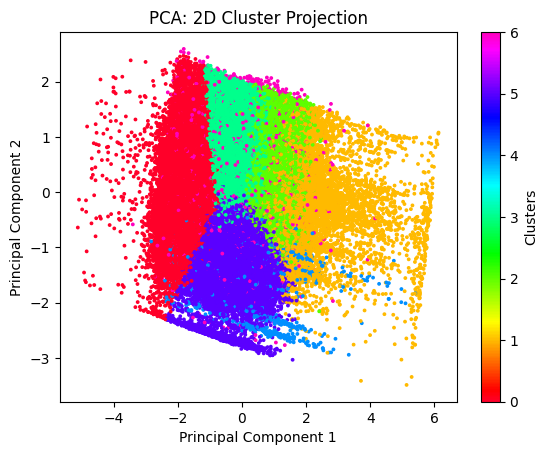

In [ ]:
# Visualize clusters using PCA components
rng = np.random.RandomState(1)
analysis_sample = rng.choice(principal_components.shape[0], 200000, replace=False)
scatter = plt.scatter(principal_components[analysis_sample,0],
                      principal_components[analysis_sample,1],
                      c=labels[analysis_sample],
                      s = 3,
                      cmap = 'gist_rainbow')
plt.colorbar(scatter, label='Clusters')

# Set title and labels
plt.title('PCA: 2D Cluster Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

This graph is based on the two first principal components, which explain around 48% of the variance. This limits the clarity of our results in exchange for creating a graph that is readable by humans. Our observations here are:

- The large, more strongly delineated than others **red** and **dark blue** clusters correspond to our ***long distance trips*** and ***morning trips***. This suggests that these features create strong separation in clustering and are good for determining patterns in taxi behavior.

- The **yellow** and **green clusters** are the ***short trip clusters***. The **teal cluster** is the ***medium-lenght trip*** cluster. We can see that they blend with each other, suggesting that the difference between short and medium-lenght trips is not as significant as with long trips, and that these are likely an artificial separation caused by our choice of k = 7.

- **The purple cluster** is ***group trips***, while the **light blue cluster** is ***rainy days***. We can see that those do not have a strong shape, and instead are scattered inside other clusters. This suggests that, while there is an underlying pattern, it is weak and probably better explained by other principal components of the PCA.

### 4.5. Silhouette and Davies-Bouldin Scores

In [ ]:
# Compute Silhouette Score
silhouette_sample = rng.choice(principal_components.shape[0], 50000, replace=False)
silhouetteScore = silhouette_score(principal_components[silhouette_sample,:6], labels[silhouette_sample])

# Compute Davies-Bouldin Score
dbScore = davies_bouldin_score(principal_components[analysis_sample,:6], labels[analysis_sample])

# Display scores
print('Silhouette score: ' + str(silhouetteScore))
print('dbScore: ' + str(dbScore))

Silhouette score: 0.17755203
dbScore: 1.3453607580479858


- **Silhouette score** is quite low, at around 0.18. Silhouette goes from 1 to -1, with the higher score being better, as it indicates compact clusters far away from each other. However, because we are working on real world behavioral data, such well separated clusters are often impossible to obtain. We can say that the silhouette score confirms what we observed in our graph: the clusters are closely packed, to the point of overlapping, and that some act more like noise scattered through other clusters. Thus, we can see that despite our first 2 principal components accounting for only 48% of the variance of our dataset, it still creates a representative graph for our results.

<br>

- **Davies-Bouldin score** is higher than is preferable. Davies-Bouldin goes from infinity to 0, with 0 being ideal, and values under 1 being prefferable. **Our result is 1.35**. This tends to support the results of the silhouette score and the graph, showing clusters that are not well-separated: Their borders are very close and overlap often. This can be seen as a limit of clustering on real-world data.

<br>

**Limitations**:
- The KMeans algorithm prefers data that is clearly separatable in spherical clusters. Real world data is rarely as clear-cut as that, and that includes the one found in our dataset.
- **DBSCAN** could have been used to cut through noise and get less overlapping clusters, but it is computationally intensive, which would have required subsampling our dataset to a large degree. KMeans, for its limitations, allowed us to use most of our dataset.

- We did need to transform some of our data, as the `trip_distance` would have been far too influencial in an Eucledian distance based algorithm like KMeans, with its large variation, so using the propriety of logarithms to limit its influence was important. It was also important to separate `fare_amount` and `tip_amount` from being influenced by `trip_distance` and each other, by tranforming them into `log_fare_per_km` and `tip_ratio`.

<br>

## 5.Interpretation
____

### 5.1. Feature Importance:  What Drives High Tipping?

We reuse the Random Forest trained in Section 2.4.3 to interpret which features most influenced the prediction of `is_high_tip`.  
The chart below shows each feature's importance score (mean decrease in impurity across all trees).

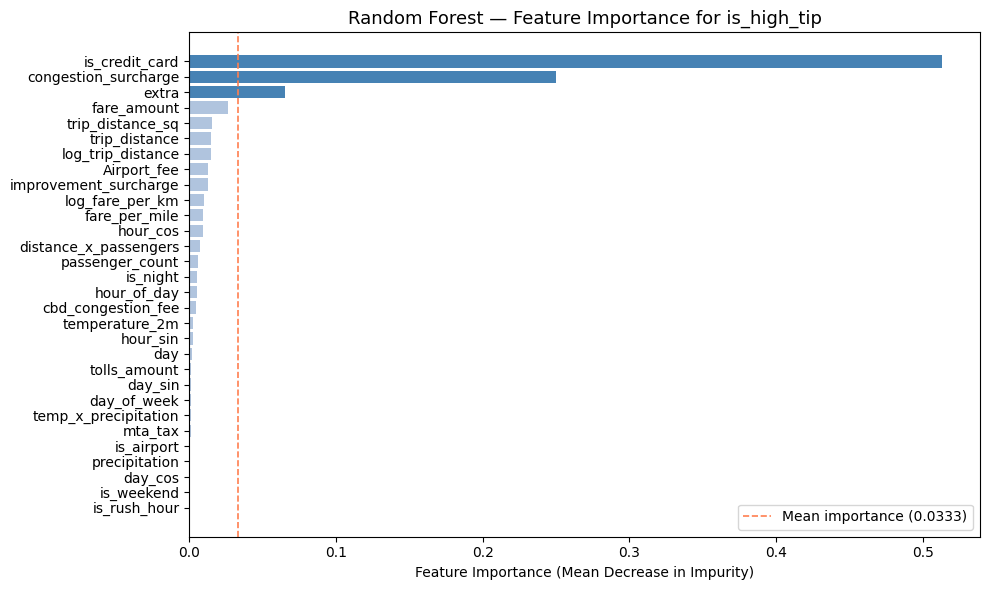

Top 5 features:
is_credit_card          0.513328
congestion_surcharge    0.250238
extra                   0.065613
fare_amount             0.026228
trip_distance_sq        0.015403
dtype: float64


In [ ]:
# ── Feature Importance Bar Chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue' if v >= rf_importance.mean() else 'lightsteelblue'
          for v in rf_importance.values]

ax.barh(rf_importance.index[::-1], rf_importance.values[::-1], color=colors[::-1])
ax.axvline(rf_importance.mean(), color='coral', linestyle='--', linewidth=1.2,
           label=f'Mean importance ({rf_importance.mean():.4f})')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest — Feature Importance for is_high_tip', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(rf_importance.head())

**Interpretation:**

- **`is_credit_card`** is the dominant feature. Cash passengers almost never tip electronically — the payment terminal is what prompts tipping. This is a structural effect of the payment system, not passenger generosity.
- **`fare_per_mile`** and **`log_fare_per_km`** rank highly, confirming that trip cost efficiency matters: passengers on expensive-per-mile trips (e.g., short airport transfers) tend to tip more.
- **`tip_ratio`** is excluded from this analysis (data leakage,  it is derived directly from `tip_amount`).
- Time features (`hour_sin/cos`, `day_sin/cos`) and weather features have low importance, suggesting tipping behavior is driven more by trip economics and payment method than by when or in what conditions the trip occurs.

> **Connection to RQ1: Supervised Learning**
- The model can classify high tippers primarily from payment method and fare structure **not** from time or weather. This simplifies the feature set needed for Section 3.
- The training phase (*Section 3.6.4 - Feature Importance*) for both Random Forest and XGBoost confirms that certain features, specifically weather data (`temperature_2m` and `precipitation`), lack significant predictive power.
- The common top predictors for both models are `improvement_surcharge`, `fare_amount` and `congestion_surcharge`.
- **Conclusion**: Based on the results of this project, customer tipping behavior is not significantly influenced by weather conditions or time of day. Instead, the primary drivers of high-tip instances are transactional features, such as payment method and fare structure.

<br>

### 5.2. Insights on Supervised Learning
Here are the key observations from supervised learning.
- **Convergence Performance**: Both **Random Forest (Bagging)** and **XGBoost (Boosting)** achieved nearly identical performance metrics. Because both models are built on **Decision Trees** and prioritized the same top features (Section 3.6.4), the results are functionally the same. This suggests that the predictive power is limited by class imbalance and label noise in the NYC Taxi data, not the choice of algorithm.


- **Accuracy Paradox**: The high Validation F1-score (0.86) is misleading. Because the dataset is imbalanced (75/25), both models effectively classified the majority "True" labels but failed to generalize the minority "False" cases. While it suggests strong performance, the significantly lower Macro F1 reveals that both models struggled to perform on the held-out set. This illustrates a primary real-world challenge with supervised learning on the unseen imbalanced dataset.


- **Feature Importance**: The feature importance plots (see Section 3.6.4) show that both models prioritize the same three predictors: `improvement_surcharge`, `fare_amount` and `congestion_surcharge`. The consistency across different architectures (Bagging vs Boosting) identifies these as reliable predictors. However, the mediocre AUC scores (0.62) reveal that feature distributions for "low tip" and "high tip" might be heavily overlapping. The current feature set cannot fully capture the complexities of customer tipping behavior. We might need to collect other features (e.g., service quality).

<br>

###5.3. Insights on Unsupervised learning
Our experience with the K-means algorithm clearly demonstrates the importance of using multiple metrics to analyse the results of a machine learning model. Each metric used revealed a different aspect of our clustering, and lead to a fuller understanding:

- The **summary** where we projected the cluster made with the **PCA** back on the original features allowed us to clearly see which features most defined each clusters. It did, however, lead to an appearance that most of the clusters were more differenciated than in reality.

- The **graph** revealed quite a bit
  - about the real structure of our clustering,
  - how the clusters were close to the point of overlapping,
  - and how some were spread through other clusters.
  
  Still, we could see that the clusters that seemed most differentiated in the summary also had more defined borders. However, since the real clustering was done in a 6-dimensional space, which would be impossible for humans to understand visually, and the chosen components for the graph only accounted for around 42% of the variance of the dataset, it would have been an error to draw conclusions from it.

- The **Silhouette** and **Davies-Bouldin Score** confirmed the intuition from the graph, that the clusters were not very well-separated. They likely overlapped at times. This is likely a reality of clustering on real world behavioral data. The summary showed that our K-Means model still gave us clustering with real meaning. We would have missed this distinction if we had only used the scores as our metric of evaluation.

> **Connection to RQ2: Unsupervised Learning**
- The K-Means clustering algorithm identified 7 distinct customer clusters based on trip distance, passenger count (occupancy), weather and temporal factors.
- The cluster distributions yields the following insights:
  - **Primary demands**: The majority of taxi demand in June–July 2025 is clustered for Short and Mid-range trips (Clusters 3 and 2). This suggests the service is primarily used for routine,
  - **Peak Morning commutes (Cluster 5)** is the 3rd biggest and consistent cluster, corresponding to the commute patterns.
  - **Long trip distance (cluster 0)** is the 4th biggest cluster, likely corresponding to airport transfers or inter-borough travel.
  - **Cluster 4 (Weather-Impacted)** contains the fewest data points. This indicates that customers were significantly less likely to use taxis during rainy periods in this dataset.


<br>

## 6.References
___

1. New York City Taxi and Limousine Commission (TLC). (2025). TLC Trip Record Data. https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page [Accessed: Feb. 26 2026]
2. New York City Taxi and Limousine Commission (TLC). (2025). Data Dictionary – Yellow Taxi Trip Records. https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf [Accessed: Feb. 26 2026]
3. Open-Meteo. (2025). Historical Weather API (New York City: June–July 2025). https://open-meteo.com/en/docs/historical-weather-api, [Accessed: Feb. 26 2026]
4. Scikit-learn Developers. (2026). Scikit-learn: Machine Learning in Python. https://scikit-learn.org/stable/ [Accessed: Apr. 2 2026]
5. Yáñez, A. (2026). COMP 333 — Week 10: Introduction to ML, Clustering & Decision Trees [Lecture notes]. Computer Science and Software Engineering, Concordia University. [Accessed: Mar. 2026]
6. Yáñez, A. (2026). COMP 333 — Week 11: Your First ML Project in Python: Step by Step [Lecture notes]. Computer Science and Software Engineering, Concordia University. [Accessed: Mar. 2026]